In [ ]:
import pandas as pd

# Load the traditional phishing email dataset
df = pd.read_csv("/content/phishing_email.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

# Display first 5 rows
df.head()

Dataset loaded successfully!
Dataset shape: (82486, 2)

Column names:
['text_combined', 'label']


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [ ]:
# Inspect labels and missing values

print("Dataset shape:", df.shape)

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nLabel percentages:")
print((df["label"].value_counts(normalize=True) * 100).round(2))

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate email texts:")
print(df["text_combined"].duplicated().sum())

Dataset shape: (82486, 2)

Label distribution:
label
1    42891
0    39595
Name: count, dtype: int64

Label percentages:
label
1    52.0
0    48.0
Name: proportion, dtype: float64

Missing values:
text_combined    0
label            0
dtype: int64

Duplicate rows:
408

Duplicate email texts:
408


In [ ]:
# Remove exact duplicate email texts

original_size = len(df)

df_clean = df.drop_duplicates(
    subset=["text_combined"],
    keep="first"
).copy()

df_clean = df_clean.reset_index(drop=True)

removed_duplicates = original_size - len(df_clean)

print("Original dataset size:", original_size)
print("Exact duplicates removed:", removed_duplicates)
print("Clean dataset size:", len(df_clean))

print("\nClean label distribution:")
print(df_clean["label"].value_counts())

print("\nClean label percentages:")
print((df_clean["label"].value_counts(normalize=True) * 100).round(2))

print("\nRemaining duplicate texts:")
print(df_clean["text_combined"].duplicated().sum())

Original dataset size: 82486
Exact duplicates removed: 408
Clean dataset size: 82078

Clean label distribution:
label
1    42845
0    39233
Name: count, dtype: int64

Clean label percentages:
label
1    52.2
0    47.8
Name: proportion, dtype: float64

Remaining duplicate texts:
0


In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# First split: 70% training, 30% temporary
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=df_clean["label"]
)

# Second split: divide the remaining 30% equally
# 15% validation and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_df["label"]
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Total clean emails:", len(df_clean))
print("\nTrain set:", len(train_df))
print("Validation set:", len(val_df))
print("Test set:", len(test_df))

print("\nTotal after split:",
      len(train_df) + len(val_df) + len(test_df))

print("\nTRAIN label distribution:")
print(train_df["label"].value_counts())

print("\nVALIDATION label distribution:")
print(val_df["label"].value_counts())

print("\nTEST label distribution:")
print(test_df["label"].value_counts())

Total clean emails: 82078

Train set: 57454
Validation set: 12312
Test set: 12312

Total after split: 82078

TRAIN label distribution:
label
1    29991
0    27463
Name: count, dtype: int64

VALIDATION label distribution:
label
1    6427
0    5885
Name: count, dtype: int64

TEST label distribution:
label
1    6427
0    5885
Name: count, dtype: int64


In [ ]:
# Check exact text overlap between datasets

train_texts = set(train_df["text_combined"])
val_texts = set(val_df["text_combined"])
test_texts = set(test_df["text_combined"])

train_val_overlap = train_texts.intersection(val_texts)
train_test_overlap = train_texts.intersection(test_texts)
val_test_overlap = val_texts.intersection(test_texts)

print("EXACT DATA LEAKAGE CHECK")
print("-------------------------")
print("Train vs Validation:", len(train_val_overlap))
print("Train vs Test:", len(train_test_overlap))
print("Validation vs Test:", len(val_test_overlap))

if not (train_val_overlap or train_test_overlap or val_test_overlap):
    print("\nPASS: No exact duplicate email texts across splits.")
else:
    print("\nWARNING: Exact duplicate texts found across splits.")

EXACT DATA LEAKAGE CHECK
-------------------------
Train vs Validation: 0
Train vs Test: 0
Validation vs Test: 0

PASS: No exact duplicate email texts across splits.


In [ ]:
# Near-duplicate leakage check
# Check for highly similar emails across train/validation/test splits

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

# Character n-grams are useful for detecting near-duplicate text
near_dup_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=50000,
    dtype=np.float32
)

print("Creating TF-IDF representation for near-duplicate checking...")

all_texts = pd.concat([
    train_df["text_combined"],
    val_df["text_combined"],
    test_df["text_combined"]
], ignore_index=True)

near_dup_vectorizer.fit(all_texts)

X_train_dup = near_dup_vectorizer.transform(train_df["text_combined"])
X_val_dup = near_dup_vectorizer.transform(val_df["text_combined"])
X_test_dup = near_dup_vectorizer.transform(test_df["text_combined"])

print("TF-IDF representations created.")
print("Feature count:", len(near_dup_vectorizer.get_feature_names_out()))

Creating TF-IDF representation for near-duplicate checking...
TF-IDF representations created.
Feature count: 50000


In [ ]:
# Find near-duplicate emails across dataset splits

from sklearn.neighbors import NearestNeighbors
import numpy as np

SIMILARITY_THRESHOLD = 0.95

def check_near_duplicates(reference_matrix, query_matrix,
                          reference_name, query_name,
                          threshold=0.95):

    model = NearestNeighbors(
        n_neighbors=1,
        metric="cosine",
        algorithm="brute",
        n_jobs=-1
    )

    model.fit(reference_matrix)

    distances, indices = model.kneighbors(query_matrix)

    similarities = 1 - distances.flatten()

    near_duplicates = np.where(similarities >= threshold)[0]

    print(f"\n{reference_name} vs {query_name}")
    print("-" * 40)

    # Number of rows in sparse matrix
    print(f"Emails checked: {query_matrix.shape[0]}")

    print(
        f"Near-duplicates (similarity >= {threshold}): "
        f"{len(near_duplicates)}"
    )

    print(f"Highest similarity: {similarities.max():.4f}")

    return near_duplicates, similarities, indices.flatten()


print("NEAR-DUPLICATE LEAKAGE CHECK")
print("Similarity threshold:", SIMILARITY_THRESHOLD)

# Train vs Validation
tv_near, tv_sim, tv_idx = check_near_duplicates(
    X_train_dup,
    X_val_dup,
    "Train",
    "Validation",
    SIMILARITY_THRESHOLD
)

# Train vs Test
tt_near, tt_sim, tt_idx = check_near_duplicates(
    X_train_dup,
    X_test_dup,
    "Train",
    "Test",
    SIMILARITY_THRESHOLD
)

# Validation vs Test
vt_near, vt_sim, vt_idx = check_near_duplicates(
    X_val_dup,
    X_test_dup,
    "Validation",
    "Test",
    SIMILARITY_THRESHOLD
)

NEAR-DUPLICATE LEAKAGE CHECK
Similarity threshold: 0.95

Train vs Validation
----------------------------------------
Emails checked: 12312
Near-duplicates (similarity >= 0.95): 2257
Highest similarity: 1.0000

Train vs Test
----------------------------------------
Emails checked: 12312
Near-duplicates (similarity >= 0.95): 2208
Highest similarity: 1.0000

Validation vs Test
----------------------------------------
Emails checked: 12312
Near-duplicates (similarity >= 0.95): 1381
Highest similarity: 1.0000


In [ ]:
# Inspect representative Train-Test near-duplicate pairs

# Sort flagged Train-Test pairs by similarity (highest first)
top_tt = sorted(
    tt_near,
    key=lambda i: tt_sim[i],
    reverse=True
)[:10]

print("TOP 10 TRAIN-TEST NEAR-DUPLICATE PAIRS")
print("=" * 80)

for number, test_i in enumerate(top_tt, start=1):

    train_i = tt_idx[test_i]
    similarity = tt_sim[test_i]

    train_text = train_df.iloc[train_i]["text_combined"]
    test_text = test_df.iloc[test_i]["text_combined"]

    train_label = train_df.iloc[train_i]["label"]
    test_label = test_df.iloc[test_i]["label"]

    print(f"\nPAIR {number}")
    print("-" * 80)
    print(f"Similarity: {similarity:.6f}")
    print(f"Train label: {train_label}")
    print(f"Test label: {test_label}")

    print("\nTRAIN EMAIL:")
    print(str(train_text)[:1000])

    print("\nTEST EMAIL:")
    print(str(test_text)[:1000])

    print("\n" + "=" * 80)

TOP 10 TRAIN-TEST NEAR-DUPLICATE PAIRS

PAIR 1
--------------------------------------------------------------------------------
Similarity: 1.000000
Train label: 1
Test label: 1

TRAIN EMAIL:
xp pro 5 adobe photoshop 8 office xp 1 oo office 2 oo 3 80 norton 2004 15 super cheaap softwares shiip countrieswe every popular softwares u need name normal 299 oo saave 249 oo adobe acrobat v 6 professional pc price 1 oo normal 449 95 saave 349 95 softwares choose full range softwares adobe alias maya autodesk borland corel crystal reports executive file maker intuit mac 321 studios macrmedia mc fee microsoft nero pinnacle systems powerquest quark red hat riverdeep roxio symantec vmware softwares 320 popular titles youcheckk 320 popular softwares siteguaaranteed super low prlce ciick check

TEST EMAIL:
office 2 oo 3 80 norton 2004 15 office xp 1 oo adobe photoshop 8 xp pro 5 super cheaap softwares shiip countrieswe every popular softwares u need name normal 299 oo saave 249 oo adobe acrobat v 6 

In [ ]:
# Create normalized fingerprints for template-level grouping

import re
import hashlib
import pandas as pd

def normalize_for_template(text):
    text = str(text).lower()

    # Replace URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' URL ', text)

    # Replace email addresses
    text = re.sub(
        r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b',
        ' EMAIL ',
        text
    )

    # Replace numbers
    text = re.sub(r'\b\d+\b', ' NUM ', text)

    # Remove punctuation/special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Apply normalization
df_grouped = df_clean.copy()

df_grouped["normalized_template"] = (
    df_grouped["text_combined"]
    .astype(str)
    .apply(normalize_for_template)
)

# Create stable template fingerprint
df_grouped["template_id"] = (
    df_grouped["normalized_template"]
    .apply(lambda x: hashlib.sha256(x.encode("utf-8")).hexdigest())
)

print("Total emails:", len(df_grouped))
print("Unique normalized templates:",
      df_grouped["template_id"].nunique())

print(
    "Emails belonging to repeated normalized templates:",
    df_grouped.duplicated(
        subset=["template_id"],
        keep=False
    ).sum()
)

print(
    "Number of template groups containing multiple emails:",
    (df_grouped.groupby("template_id").size() > 1).sum()
)

print("\nLargest template groups:")
print(
    df_grouped.groupby("template_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

Total emails: 82078
Unique normalized templates: 80756
Emails belonging to repeated normalized templates: 1627
Number of template groups containing multiple emails: 305

Largest template groups:
template_id
2d404f1499334caad94d8c9e1ad28ac69f29a5a645fc274e40f960f55dd5ce58    449
d5d160f13fa3180c01f05ae5ece1ef0c0d764733ae48fb3c8cc5397d48e4b482     85
0664e43a0bd8322e4d7f3d7c86adcce984e440e7eb3995bdc0ae3660c106e1e0     42
dc355e904f766af5adc51deaf4f951177e5741e1478e0352be596cc8d41efa0d     37
f6737ae98567d2ba8c20cfffc1addc5bf72deb85090fdd14b666a9c1b6b5ceda     36
db02c72da24cf877f7fd1cb2a1f962108e2625bd4c52ecde222679a3a1f76c05     22
9f4d1de5c170de1f71555aeb1edcbe8602932ce7521925485f486106e86caa03     21
6896dd2312bf6540901696605df11db9018a7dc188cb88b135ef16c0fd994d63     18
fb77f03d3cffbe7d79a1ba0167c7a052161c84d81aa84ffdfe04ac8b857f51cb     18
46fb277f5a805487250c9386184fe3064ae117c2779cce8e9146eee843657b4a     17
dtype: int64


In [ ]:
# Create group-aware train/validation/test split

from sklearn.model_selection import GroupShuffleSplit

RANDOM_SEED = 42

# --------------------------------------------------
# First split:
# 70% Train / 30% Temporary
# Keep template groups together
# --------------------------------------------------

gss1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=RANDOM_SEED
)

train_idx, temp_idx = next(
    gss1.split(
        df_grouped,
        y=df_grouped["label"],
        groups=df_grouped["template_id"]
    )
)

train_group_df = df_grouped.iloc[train_idx].copy()
temp_group_df = df_grouped.iloc[temp_idx].copy()


# --------------------------------------------------
# Second split:
# Divide temporary data approximately equally
# into Validation and Test
# --------------------------------------------------

gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=RANDOM_SEED
)

val_idx, test_idx = next(
    gss2.split(
        temp_group_df,
        y=temp_group_df["label"],
        groups=temp_group_df["template_id"]
    )
)

val_group_df = temp_group_df.iloc[val_idx].copy()
test_group_df = temp_group_df.iloc[test_idx].copy()


# Reset indexes
train_group_df = train_group_df.reset_index(drop=True)
val_group_df = val_group_df.reset_index(drop=True)
test_group_df = test_group_df.reset_index(drop=True)


# --------------------------------------------------
# Display split sizes
# --------------------------------------------------

print("LEAKAGE-CONTROLLED SPLIT")
print("=" * 50)

print("Total emails:", len(df_grouped))
print("Train:", len(train_group_df))
print("Validation:", len(val_group_df))
print("Test:", len(test_group_df))

print(
    "Total after split:",
    len(train_group_df)
    + len(val_group_df)
    + len(test_group_df)
)


# --------------------------------------------------
# Label distributions
# --------------------------------------------------

for name, data in [
    ("TRAIN", train_group_df),
    ("VALIDATION", val_group_df),
    ("TEST", test_group_df)
]:
    print(f"\n{name}")
    print("-" * 30)

    print(data["label"].value_counts())

    print("\nPercentages:")
    print(
        (data["label"]
         .value_counts(normalize=True)
         * 100)
        .round(2)
    )


# --------------------------------------------------
# Check template leakage
# --------------------------------------------------

train_templates = set(train_group_df["template_id"])
val_templates = set(val_group_df["template_id"])
test_templates = set(test_group_df["template_id"])

print("\nTEMPLATE LEAKAGE CHECK")
print("=" * 50)

print(
    "Train vs Validation:",
    len(train_templates & val_templates)
)

print(
    "Train vs Test:",
    len(train_templates & test_templates)
)

print(
    "Validation vs Test:",
    len(val_templates & test_templates)
)

LEAKAGE-CONTROLLED SPLIT
Total emails: 82078
Train: 57541
Validation: 12176
Test: 12361
Total after split: 82078

TRAIN
------------------------------
label
1    29981
0    27560
Name: count, dtype: int64

Percentages:
label
1    52.1
0    47.9
Name: proportion, dtype: float64

VALIDATION
------------------------------
label
1    6433
0    5743
Name: count, dtype: int64

Percentages:
label
1    52.83
0    47.17
Name: proportion, dtype: float64

TEST
------------------------------
label
1    6431
0    5930
Name: count, dtype: int64

Percentages:
label
1    52.03
0    47.97
Name: proportion, dtype: float64

TEMPLATE LEAKAGE CHECK
Train vs Validation: 0
Train vs Test: 0
Validation vs Test: 0


In [ ]:
# Near-duplicate check on leakage-controlled split

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

SIMILARITY_THRESHOLD = 0.95

# Create character-level TF-IDF representation
controlled_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=50000,
    dtype=np.float32
)

all_controlled_texts = pd.concat([
    train_group_df["text_combined"],
    val_group_df["text_combined"],
    test_group_df["text_combined"]
], ignore_index=True)

print("Creating TF-IDF representation...")

controlled_vectorizer.fit(all_controlled_texts)

X_train_controlled = controlled_vectorizer.transform(
    train_group_df["text_combined"]
)

X_val_controlled = controlled_vectorizer.transform(
    val_group_df["text_combined"]
)

X_test_controlled = controlled_vectorizer.transform(
    test_group_df["text_combined"]
)

print("TF-IDF representation complete.")
print(
    "Feature count:",
    len(controlled_vectorizer.get_feature_names_out())
)


def check_controlled_near_duplicates(
    reference_matrix,
    query_matrix,
    reference_name,
    query_name,
    threshold=0.95
):

    model = NearestNeighbors(
        n_neighbors=1,
        metric="cosine",
        algorithm="brute",
        n_jobs=-1
    )

    model.fit(reference_matrix)

    distances, indices = model.kneighbors(query_matrix)

    similarities = 1 - distances.flatten()

    flagged = np.where(
        similarities >= threshold
    )[0]

    print(f"\n{reference_name} vs {query_name}")
    print("-" * 40)

    print(
        f"Near-duplicates (similarity >= {threshold}):",
        len(flagged)
    )

    print(
        "Highest similarity:",
        f"{similarities.max():.6f}"
    )

    return flagged, similarities, indices.flatten()


print("\nFINAL NEAR-DUPLICATE CHECK")
print("=" * 50)

new_tv_near, new_tv_sim, new_tv_idx = (
    check_controlled_near_duplicates(
        X_train_controlled,
        X_val_controlled,
        "Train",
        "Validation",
        SIMILARITY_THRESHOLD
    )
)

new_tt_near, new_tt_sim, new_tt_idx = (
    check_controlled_near_duplicates(
        X_train_controlled,
        X_test_controlled,
        "Train",
        "Test",
        SIMILARITY_THRESHOLD
    )
)

new_vt_near, new_vt_sim, new_vt_idx = (
    check_controlled_near_duplicates(
        X_val_controlled,
        X_test_controlled,
        "Validation",
        "Test",
        SIMILARITY_THRESHOLD
    )
)

Creating TF-IDF representation...
TF-IDF representation complete.
Feature count: 50000

FINAL NEAR-DUPLICATE CHECK

Train vs Validation
----------------------------------------
Near-duplicates (similarity >= 0.95): 2143
Highest similarity: 0.999964

Train vs Test
----------------------------------------
Near-duplicates (similarity >= 0.95): 2082
Highest similarity: 0.999995

Validation vs Test
----------------------------------------
Near-duplicates (similarity >= 0.95): 1290
Highest similarity: 1.000000


In [ ]:
# Remove near-duplicates of TRAINING data
# from validation and traditional test sets

SIMILARITY_THRESHOLD = 0.95

# Indices already identified in Step 9C
# These are validation/test messages whose closest training
# message has similarity >= 0.95.

val_remove_indices = set(new_tv_near.tolist())
test_remove_indices = set(new_tt_near.tolist())

print("Before filtering")
print("------------------------------")
print("Training:", len(train_group_df))
print("Validation:", len(val_group_df))
print("Test:", len(test_group_df))

print("\nNear-duplicates relative to training")
print("------------------------------")
print("Validation to remove:", len(val_remove_indices))
print("Test to remove:", len(test_remove_indices))


# Keep training unchanged
train_final = train_group_df.copy()

# Remove near-duplicates from validation
val_final = val_group_df[
    ~val_group_df.index.isin(val_remove_indices)
].copy()

# Remove near-duplicates from test
test_final = test_group_df[
    ~test_group_df.index.isin(test_remove_indices)
].copy()


# Reset indexes
train_final = train_final.reset_index(drop=True)
val_final = val_final.reset_index(drop=True)
test_final = test_final.reset_index(drop=True)


print("\nFINAL DATASET SIZES")
print("=" * 40)

print("Training:", len(train_final))
print("Validation:", len(val_final))
print("Traditional Test:", len(test_final))


print("\nFINAL LABEL DISTRIBUTIONS")
print("=" * 40)

for name, data in [
    ("TRAIN", train_final),
    ("VALIDATION", val_final),
    ("TEST", test_final)
]:

    print(f"\n{name}")
    print(data["label"].value_counts())

    print("Percentages:")
    print(
        (
            data["label"]
            .value_counts(normalize=True)
            * 100
        ).round(2)
    )

Before filtering
------------------------------
Training: 57541
Validation: 12176
Test: 12361

Near-duplicates relative to training
------------------------------
Validation to remove: 2143
Test to remove: 2082

FINAL DATASET SIZES
Training: 57541
Validation: 10033
Traditional Test: 10279

FINAL LABEL DISTRIBUTIONS

TRAIN
label
1    29981
0    27560
Name: count, dtype: int64
Percentages:
label
1    52.1
0    47.9
Name: proportion, dtype: float64

VALIDATION
label
1    5107
0    4926
Name: count, dtype: int64
Percentages:
label
1    50.9
0    49.1
Name: proportion, dtype: float64

TEST
label
0    5143
1    5136
Name: count, dtype: int64
Percentages:
label
0    50.03
1    49.97
Name: proportion, dtype: float64


In [ ]:
# Save/freeze final experimental datasets

# Keep only the columns needed for modeling
columns_to_save = ["text_combined", "label"]

train_final[columns_to_save].to_csv(
    "/content/train_final.csv",
    index=False
)

val_final[columns_to_save].to_csv(
    "/content/validation_final.csv",
    index=False
)

test_final[columns_to_save].to_csv(
    "/content/traditional_test_final.csv",
    index=False
)

print("Final datasets saved successfully.")
print("-----------------------------------")
print("train_final.csv:", len(train_final))
print("validation_final.csv:", len(val_final))
print("traditional_test_final.csv:", len(test_final))

Final datasets saved successfully.
-----------------------------------
train_final.csv: 57541
validation_final.csv: 10033
traditional_test_final.csv: 10279


In [ ]:
# Verify frozen datasets

train_check = pd.read_csv("/content/train_final.csv")
val_check = pd.read_csv("/content/validation_final.csv")
test_check = pd.read_csv("/content/traditional_test_final.csv")

print("VERIFICATION")
print("=" * 40)

print("Training:", train_check.shape)
print("Validation:", val_check.shape)
print("Test:", test_check.shape)

print("\nMissing values:")
print("Train:", train_check.isnull().sum().sum())
print("Validation:", val_check.isnull().sum().sum())
print("Test:", test_check.isnull().sum().sum())

print("\nExact duplicate text within each set:")
print("Train:", train_check["text_combined"].duplicated().sum())
print("Validation:", val_check["text_combined"].duplicated().sum())
print("Test:", test_check["text_combined"].duplicated().sum())

VERIFICATION
Training: (57541, 2)
Validation: (10033, 2)
Test: (10279, 2)

Missing values:
Train: 0
Validation: 0
Test: 0

Exact duplicate text within each set:
Train: 0
Validation: 0
Test: 0


In [ ]:
# Train TF-IDF + LinearSVC baseline

import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# Model settings
TFIDF_MAX_FEATURES = 50000
TFIDF_NGRAM_RANGE = (1, 2)
SVM_C = 1.0
RANDOM_SEED = 42

print("TF-IDF + LinearSVC SETTINGS")
print("=" * 45)
print("TF-IDF max features:", TFIDF_MAX_FEATURES)
print("TF-IDF n-gram range:", TFIDF_NGRAM_RANGE)
print("LinearSVC C:", SVM_C)
print("Random seed:", RANDOM_SEED)

# Create TF-IDF vectorizer
svm_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    lowercase=True,
    sublinear_tf=True,
    dtype="float32"
)

print("\nCreating TF-IDF features...")

start_time = time.time()

X_train_svm = svm_vectorizer.fit_transform(
    train_final["text_combined"]
)

X_val_svm = svm_vectorizer.transform(
    val_final["text_combined"]
)

X_test_svm = svm_vectorizer.transform(
    test_final["text_combined"]
)

y_train = train_final["label"].values
y_val = val_final["label"].values
y_test = test_final["label"].values

print("Training matrix:", X_train_svm.shape)
print("Validation matrix:", X_val_svm.shape)
print("Test matrix:", X_test_svm.shape)

# Train LinearSVC
svm_model = LinearSVC(
    C=SVM_C,
    random_state=RANDOM_SEED
)

print("\nTraining LinearSVC...")

svm_model.fit(X_train_svm, y_train)

svm_training_time = time.time() - start_time

print("Training completed.")
print(f"Total TF-IDF + training time: {svm_training_time:.2f} seconds")

TF-IDF + LinearSVC SETTINGS
TF-IDF max features: 50000
TF-IDF n-gram range: (1, 2)
LinearSVC C: 1.0
Random seed: 42

Creating TF-IDF features...


/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float32 'dtype' will be converted to np.float64.
  warnings.warn(


Training matrix: (57541, 50000)
Validation matrix: (10033, 50000)
Test matrix: (10279, 50000)

Training LinearSVC...
Training completed.
Total TF-IDF + training time: 66.71 seconds


In [ ]:
# Evaluate SVM on validation set

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

svm_val_pred = svm_model.predict(X_val_svm)

val_accuracy = accuracy_score(y_val, svm_val_pred)
val_precision = precision_score(y_val, svm_val_pred, pos_label=1)
val_recall = recall_score(y_val, svm_val_pred, pos_label=1)
val_f1 = f1_score(y_val, svm_val_pred, pos_label=1)

print("SVM VALIDATION RESULTS")
print("=" * 40)

print(f"Accuracy:           {val_accuracy:.4f}")
print(f"Phishing Precision: {val_precision:.4f}")
print(f"Phishing Recall:    {val_recall:.4f}")
print(f"Phishing F1-score:  {val_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, svm_val_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        svm_val_pred,
        target_names=["Legitimate", "Phishing"],
        digits=4
    )
)

SVM VALIDATION RESULTS
Accuracy:           0.9911
Phishing Precision: 0.9887
Phishing Recall:    0.9939
Phishing F1-score:  0.9913

Confusion Matrix:
[[4868   58]
 [  31 5076]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9937    0.9882    0.9909      4926
    Phishing     0.9887    0.9939    0.9913      5107

    accuracy                         0.9911     10033
   macro avg     0.9912    0.9911    0.9911     10033
weighted avg     0.9911    0.9911    0.9911     10033



SVM + TF-IDF — TRADITIONAL TEST RESULTS
Accuracy:           0.9912
Phishing Precision: 0.9893
Phishing Recall:    0.9932
Phishing F1-score:  0.9913

Confusion Matrix:
[[5088   55]
 [  35 5101]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9932    0.9893    0.9912      5143
    Phishing     0.9893    0.9932    0.9913      5136

    accuracy                         0.9912     10279
   macro avg     0.9913    0.9912    0.9912     10279
weighted avg     0.9913    0.9912    0.9912     10279



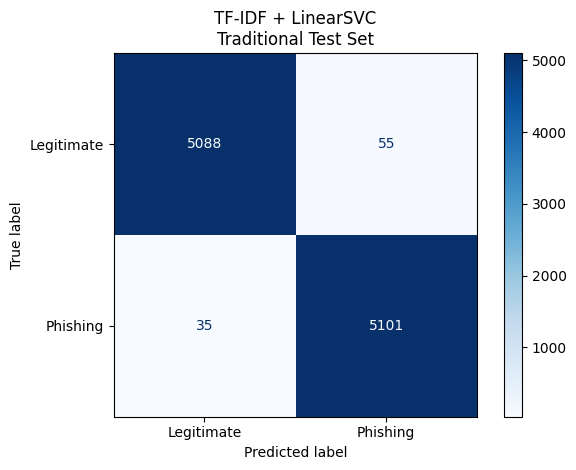

In [ ]:
# Final SVM evaluation on traditional test set

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Predict untouched traditional test set
svm_test_pred = svm_model.predict(X_test_svm)

# Calculate required metrics
svm_trad_accuracy = accuracy_score(
    y_test, svm_test_pred
)

svm_trad_precision = precision_score(
    y_test, svm_test_pred,
    pos_label=1
)

svm_trad_recall = recall_score(
    y_test, svm_test_pred,
    pos_label=1
)

svm_trad_f1 = f1_score(
    y_test, svm_test_pred,
    pos_label=1
)

svm_trad_cm = confusion_matrix(
    y_test, svm_test_pred
)

# Print results
print("SVM + TF-IDF — TRADITIONAL TEST RESULTS")
print("=" * 50)

print(f"Accuracy:           {svm_trad_accuracy:.4f}")
print(f"Phishing Precision: {svm_trad_precision:.4f}")
print(f"Phishing Recall:    {svm_trad_recall:.4f}")
print(f"Phishing F1-score:  {svm_trad_f1:.4f}")

print("\nConfusion Matrix:")
print(svm_trad_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svm_test_pred,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        digits=4
    )
)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_trad_cm,
    display_labels=[
        "Legitimate",
        "Phishing"
    ]
)

disp.plot(
    values_format="d",
    cmap="Blues"
)

plt.title(
    "TF-IDF + LinearSVC\nTraditional Test Set"
)

plt.tight_layout()

# Save figure for conference paper
plt.savefig(
    "/content/svm_traditional_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Inspect E-PhishLLM dataset

import json
import pandas as pd

E_PHISH_PATH = "/content/ephishLLM.json"

with open(E_PHISH_PATH, "r", encoding="utf-8") as f:
    ephish_raw = json.load(f)

print("Python object type:", type(ephish_raw))

if isinstance(ephish_raw, list):
    print("Number of records:", len(ephish_raw))
    print("\nFirst record:")
    print(ephish_raw[0])

elif isinstance(ephish_raw, dict):
    print("Top-level keys:")
    print(list(ephish_raw.keys()))

    print("\nPreview:")
    for key in list(ephish_raw.keys())[:5]:
        print(f"\nKEY: {key}")
        print(str(ephish_raw[key])[:1000])

Python object type: <class 'list'>
Number of records: 16616

First record:
{'Subject': 'Aggiornamento sul progetto di trasformazione digitale: prossimi passi', 'Body': "Ciao Silvano,\n\nVolevo aggiornarti sugli ultimi sviluppi del nostro progetto di trasformazione digitale con [Nome SME]. Abbiamo programmato una riunione per giovedì alle 15:00 per discutere lo stato attuale del progetto e pianificare i prossimi passi. È essenziale che ci confrontiamo su alcune decisioni chiave per garantire il rispetto dei tempi previsti.\n\nDurante l'incontro, mi piacerebbe sentire le tue considerazioni sui miglioramenti che possiamo apportare, soprattutto per quanto riguarda l'efficienza delle soluzioni cloud che stiamo implementando. La tua esperienza è fondamentale per il successo di questo progetto.\n\nA presto,\n\nCarlo Rossi\nProject Manager", 'type': 0, 'Language': 'it'}


In [ ]:
# Extract and inspect English E-PhishLLM records

ephish_df = pd.DataFrame(ephish_raw)

print("E-PhishLLM DATASET")
print("=" * 50)

print("Total records:", len(ephish_df))

print("\nColumns:")
print(ephish_df.columns.tolist())

print("\nLanguage distribution:")
print(ephish_df["Language"].value_counts())

print("\nType distribution (entire dataset):")
print(ephish_df["type"].value_counts())

# Select English records only
ephish_en = ephish_df[
    ephish_df["Language"].astype(str).str.lower() == "en"
].copy()

ephish_en = ephish_en.reset_index(drop=True)

print("\n" + "=" * 50)
print("ENGLISH E-PhishLLM")
print("=" * 50)

print("English records:", len(ephish_en))

print("\nEnglish type distribution:")
print(ephish_en["type"].value_counts())

print("\nMissing values:")
print(
    ephish_en[
        ["Subject", "Body", "type", "Language"]
    ].isnull().sum()
)

print("\nFirst 3 English records:")
display(
    ephish_en[
        ["Subject", "Body", "type", "Language"]
    ].head(3)
)

E-PhishLLM DATASET
Total records: 16616

Columns:
['Subject', 'Body', 'type', 'Language']

Language distribution:
Language
en       11502
it        2701
de        2349
es          35
fr          12
sv           5
da           4
zh-cn        3
no           3
ja           2
Name: count, dtype: int64

Type distribution (entire dataset):
type
0    8398
1    8218
Name: count, dtype: int64

ENGLISH E-PhishLLM
English records: 11502

English type distribution:
type
1    5996
0    5506
Name: count, dtype: int64

Missing values:
Subject     0
Body        0
type        0
Language    0
dtype: int64

First 3 English records:


,Subject,Body,type,Language
0,Feedback sulla collaborazione con soluzioni cloud,"Hi Silvano,\n\nI hope this finds you well. I w...",0,en
1,Discussion on Software Features and Customizat...,"Hi Melissa,\n\nI hope this message finds you w...",0,en
2,Exploring Collaboration Opportunities on Digit...,"Dear Melissa,\n\nI hope this email finds you w...",0,en


In [ ]:
# Inspect examples from each E-PhishLLM type
# This helps verify the label mapping before evaluation.

for label_type in sorted(ephish_en["type"].unique()):

    print("\n" + "=" * 80)
    print(f"TYPE = {label_type}")
    print("=" * 80)

    examples = ephish_en[
        ephish_en["type"] == label_type
    ].head(3)

    for i, row in examples.iterrows():

        print("\nSUBJECT:")
        print(row["Subject"])

        print("\nBODY:")
        print(str(row["Body"])[:1000])

        print("\n" + "-" * 80)


TYPE = 0

SUBJECT:
Feedback sulla collaborazione con soluzioni cloud

BODY:
Hi Silvano,

I hope this finds you well. I wanted to share some feedback regarding our recent collaboration on the cloud solutions project. Overall, the partnership is progressing well, but there are a few areas we can improve to enhance efficiency.

Firstly, optimizing the deployment timeline would significantly benefit the project. Let's focus on streamlining some of the communication processes with the development team to ensure quicker turnarounds.

Please let me know a convenient time for a follow-up discussion so we can brainstorm effective strategies moving forward.

Best regards,

Markus Schmidt
Technical Partner Manager

--------------------------------------------------------------------------------

SUBJECT:
Discussion on Software Features and Customization Options

BODY:
Hi Melissa,

I hope this message finds you well. We've received an inquiry from the client regarding the features and customizati

In [ ]:
# Prepare English E-PhishLLM for cross-domain evaluation

# Combine subject and body into one text field
ephish_en["text_combined"] = (
    ephish_en["Subject"].astype(str).str.strip()
    + " "
    + ephish_en["Body"].astype(str).str.strip()
)

# E-PhishLLM type mapping:
# 0 = Legitimate
# 1 = Phishing
ephish_en["label"] = ephish_en["type"].astype(int)

print("ENGLISH E-PhishLLM PREPARATION")
print("=" * 50)

print("Total English emails:", len(ephish_en))

print("\nLabel distribution:")
print(ephish_en["label"].value_counts())

print("\nLabel percentages:")
print(
    (
        ephish_en["label"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

print("\nMissing combined text:")
print(ephish_en["text_combined"].isnull().sum())

print("\nDuplicate combined texts:")
print(ephish_en["text_combined"].duplicated().sum())

print("\nExample combined text:")
print(ephish_en["text_combined"].iloc[0][:1000])

ENGLISH E-PhishLLM PREPARATION
Total English emails: 11502

Label distribution:
label
1    5996
0    5506
Name: count, dtype: int64

Label percentages:
label
1    52.13
0    47.87
Name: proportion, dtype: float64

Missing combined text:
0

Duplicate combined texts:
0

Example combined text:
Feedback sulla collaborazione con soluzioni cloud Hi Silvano,

I hope this finds you well. I wanted to share some feedback regarding our recent collaboration on the cloud solutions project. Overall, the partnership is progressing well, but there are a few areas we can improve to enhance efficiency.

Firstly, optimizing the deployment timeline would significantly benefit the project. Let's focus on streamlining some of the communication processes with the development team to ensure quicker turnarounds.

Please let me know a convenient time for a follow-up discussion so we can brainstorm effective strategies moving forward.

Best regards,

Markus Schmidt
Technical Partner Manager


SVM + TF-IDF — E-PhishLLM RESULTS
Accuracy:           0.7393
Phishing Precision: 0.8094
Phishing Recall:    0.6538
Phishing F1-score:  0.7233

Confusion Matrix:
[[4583  923]
 [2076 3920]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.6882    0.8324    0.7535      5506
    Phishing     0.8094    0.6538    0.7233      5996

    accuracy                         0.7393     11502
   macro avg     0.7488    0.7431    0.7384     11502
weighted avg     0.7514    0.7393    0.7378     11502



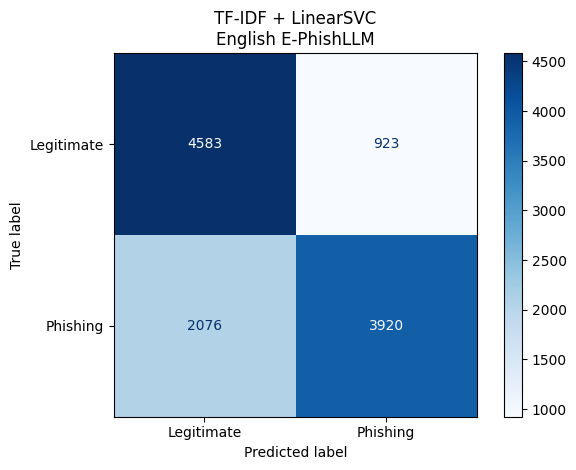

In [ ]:
# Cross-domain evaluation
# Existing SVM trained ONLY on traditional phishing data
# NO retraining on E-PhishLLM

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# IMPORTANT:
# transform() only — DO NOT fit the vectorizer again
X_ephish_svm = svm_vectorizer.transform(
    ephish_en["text_combined"]
)

y_ephish = ephish_en["label"].values

# Predict using the already-trained traditional SVM
svm_ephish_pred = svm_model.predict(X_ephish_svm)

# Required metrics
svm_ephish_accuracy = accuracy_score(
    y_ephish,
    svm_ephish_pred
)

svm_ephish_precision = precision_score(
    y_ephish,
    svm_ephish_pred,
    pos_label=1
)

svm_ephish_recall = recall_score(
    y_ephish,
    svm_ephish_pred,
    pos_label=1
)

svm_ephish_f1 = f1_score(
    y_ephish,
    svm_ephish_pred,
    pos_label=1
)

svm_ephish_cm = confusion_matrix(
    y_ephish,
    svm_ephish_pred
)

print("SVM + TF-IDF — E-PhishLLM RESULTS")
print("=" * 50)

print(f"Accuracy:           {svm_ephish_accuracy:.4f}")
print(f"Phishing Precision: {svm_ephish_precision:.4f}")
print(f"Phishing Recall:    {svm_ephish_recall:.4f}")
print(f"Phishing F1-score:  {svm_ephish_f1:.4f}")

print("\nConfusion Matrix:")
print(svm_ephish_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_ephish,
        svm_ephish_pred,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        digits=4
    )
)

# Confusion matrix figure
disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_ephish_cm,
    display_labels=[
        "Legitimate",
        "Phishing"
    ]
)

disp.plot(
    values_format="d",
    cmap="Blues"
)

plt.title(
    "TF-IDF + LinearSVC\nEnglish E-PhishLLM"
)

plt.tight_layout()

plt.savefig(
    "/content/svm_ephishllm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# SVM cross-domain generalization analysis

svm_results = pd.DataFrame({
    "Dataset": [
        "Traditional Test",
        "English E-PhishLLM"
    ],
    "Accuracy": [
        svm_trad_accuracy,
        svm_ephish_accuracy
    ],
    "Phishing Precision": [
        svm_trad_precision,
        svm_ephish_precision
    ],
    "Phishing Recall": [
        svm_trad_recall,
        svm_ephish_recall
    ],
    "Phishing F1": [
        svm_trad_f1,
        svm_ephish_f1
    ]
})

print("SVM RESULTS")
print("=" * 70)
display(svm_results.round(4))

accuracy_drop = svm_trad_accuracy - svm_ephish_accuracy
precision_drop = svm_trad_precision - svm_ephish_precision
recall_drop = svm_trad_recall - svm_ephish_recall
f1_drop = svm_trad_f1 - svm_ephish_f1

print("\nSVM GENERALIZATION GAP")
print("=" * 50)
print(f"Accuracy drop:           {accuracy_drop:.4f} ({accuracy_drop*100:.2f} percentage points)")
print(f"Phishing Precision drop: {precision_drop:.4f} ({precision_drop*100:.2f} percentage points)")
print(f"Phishing Recall drop:    {recall_drop:.4f} ({recall_drop*100:.2f} percentage points)")
print(f"Phishing F1 drop:        {f1_drop:.4f} ({f1_drop*100:.2f} percentage points)")

# Save for later paper tables
svm_results.to_csv(
    "/content/svm_final_results.csv",
    index=False
)

print("\nSaved: svm_final_results.csv")

SVM RESULTS


,Dataset,Accuracy,Phishing Precision,Phishing Recall,Phishing F1
0,Traditional Test,0.9912,0.9893,0.9932,0.9913
1,English E-PhishLLM,0.7393,0.8094,0.6538,0.7233



SVM GENERALIZATION GAP
Accuracy drop:           0.2520 (25.20 percentage points)
Phishing Precision drop: 0.1799 (17.99 percentage points)
Phishing Recall drop:    0.3394 (33.94 percentage points)
Phishing F1 drop:        0.2679 (26.79 percentage points)

Saved: svm_final_results.csv


In [ ]:
import torch
import platform

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

print("Python version:", platform.python_version())

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8
Python version: 3.13.15


In [ ]:
import pandas as pd
import json

# Load the three frozen traditional datasets
train_df = pd.read_csv("/content/train_final.csv")
val_df = pd.read_csv("/content/validation_final.csv")
test_df = pd.read_csv("/content/traditional_test_final.csv")

print("=== FROZEN DATASET VERIFICATION ===")
print("Training shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Traditional test shape:", test_df.shape)

print("\nTraining columns:", train_df.columns.tolist())
print("Validation columns:", val_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

print("\n=== CLASS DISTRIBUTIONS ===")

print("\nTraining:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation:")
print(val_df["label"].value_counts().sort_index())

print("\nTraditional Test:")
print(test_df["label"].value_counts().sort_index())

print("\n=== MISSING VALUES ===")
print("Training:", train_df.isnull().sum().sum())
print("Validation:", val_df.isnull().sum().sum())
print("Test:", test_df.isnull().sum().sum())

# Check E-PhishLLM file
with open("/content/ephishLLM.json", "r", encoding="utf-8") as f:
    ephish_data = json.load(f)

print("\nE-PhishLLM total records:", len(ephish_data))

=== FROZEN DATASET VERIFICATION ===
Training shape: (57541, 2)
Validation shape: (10033, 2)
Traditional test shape: (10279, 2)

Training columns: ['text_combined', 'label']
Validation columns: ['text_combined', 'label']
Test columns: ['text_combined', 'label']

=== CLASS DISTRIBUTIONS ===

Training:
label
0    27560
1    29981
Name: count, dtype: int64

Validation:
label
0    4926
1    5107
Name: count, dtype: int64

Traditional Test:
label
0    5143
1    5136
Name: count, dtype: int64

=== MISSING VALUES ===
Training: 0
Validation: 0
Test: 0

E-PhishLLM total records: 16616


In [ ]:
!pip -q install -U transformers datasets accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 98.6 MB/s eta 0:00:00


In [ ]:
import transformers
import datasets
import accelerate
import sklearn

print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Accelerate:", accelerate.__version__)
print("Scikit-learn:", sklearn.__version__)

Transformers: 5.17.0
Datasets: 5.0.1
Accelerate: 1.15.0
Scikit-learn: 1.9.1


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Model:", MODEL_NAME)
print("Tokenizer:", tokenizer.__class__.__name__)
print("Maximum sequence length for experiment:", MAX_LENGTH)
print("Tokenizer vocabulary size:", tokenizer.vocab_size)

# Quick test
sample_text = train_df["text_combined"].iloc[0]

sample_tokens = tokenizer(
    sample_text,
    truncation=True,
    max_length=MAX_LENGTH
)

print("\nTokenizer test successful.")
print("Sample token count:", len(sample_tokens["input_ids"]))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Model: distilbert-base-uncased
Tokenizer: BertTokenizer
Maximum sequence length for experiment: 256
Tokenizer vocabulary size: 30522

Tokenizer test successful.
Sample token count: 24


In [ ]:
from datasets import Dataset

# Convert frozen pandas DataFrames to Hugging Face datasets
train_dataset = Dataset.from_pandas(
    train_df[["text_combined", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["text_combined", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["text_combined", "label"]],
    preserve_index=False
)

# Tokenization function
def tokenize_function(batch):
    return tokenizer(
        batch["text_combined"],
        truncation=True,
        max_length=MAX_LENGTH
    )

# Tokenize datasets
train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text_combined"]
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text_combined"]
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text_combined"]
)

print("\n=== TOKENIZATION COMPLETE ===")
print("Training samples:", len(train_tokenized))
print("Validation samples:", len(val_tokenized))
print("Traditional test samples:", len(test_tokenized))

print("\nTraining columns:", train_tokenized.column_names)
print("Validation columns:", val_tokenized.column_names)
print("Test columns:", test_tokenized.column_names)

print("\nFirst tokenized sample length:",
      len(train_tokenized[0]["input_ids"]))

Map:   0%|          | 0/57541 [00:00<?, ? examples/s]

Map:   0%|          | 0/10033 [00:00<?, ? examples/s]

Map:   0%|          | 0/10279 [00:00<?, ? examples/s]


=== TOKENIZATION COMPLETE ===
Training samples: 57541
Validation samples: 10033
Traditional test samples: 10279

Training columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Validation columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Test columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']

First tokenized sample length: 24


In [ ]:
import numpy as np
import torch
import random

from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    set_seed
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

# Load DistilBERT for binary classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# Dynamic padding
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

# Evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        pos_label=1,
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("=== DISTILBERT INITIALIZATION ===")
print("Model:", MODEL_NAME)
print("Number of labels:", model.config.num_labels)
print("Random seed:", SEED)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Model initialization successful.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


=== DISTILBERT INITIALIZATION ===
Model: distilbert-base-uncased
Number of labels: 2
Random seed: 42
GPU available: True
GPU: Tesla T4
Model initialization successful.


In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="/content/distilbert_phishing_model",

    # Training settings
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,

    # Evaluate and save after each epoch
    eval_strategy="epoch",
    save_strategy="epoch",

    # Keep the best validation model
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # Reproducibility
    seed=42,
    data_seed=42,

    # Logging
    logging_strategy="steps",
    logging_steps=500,

    # Keep storage manageable
    save_total_limit=2,

    # T4 supports mixed precision
    fp16=True,

    # Do not send results to external services
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("=== TRAINING CONFIGURATION ===")
print("Model:", MODEL_NAME)
print("Max sequence length:", MAX_LENGTH)
print("Epochs:", training_args.num_train_epochs)
print("Learning rate:", training_args.learning_rate)
print("Train batch size:", training_args.per_device_train_batch_size)
print("Evaluation batch size:", training_args.per_device_eval_batch_size)
print("Weight decay:", training_args.weight_decay)
print("Optimizer: AdamW")
print("FP16:", training_args.fp16)
print("Random seed:", training_args.seed)
print("Best model metric:", training_args.metric_for_best_model)
print("GPU:", torch.cuda.get_device_name(0))

print("\nTrainer created successfully.")

=== TRAINING CONFIGURATION ===
Model: distilbert-base-uncased
Max sequence length: 256
Epochs: 3
Learning rate: 2e-05
Train batch size: 16
Evaluation batch size: 32
Weight decay: 0.01
Optimizer: AdamW
FP16: True
Random seed: 42
Best model metric: f1
GPU: Tesla T4

Trainer created successfully.


In [ ]:
import time

print("=== STARTING DISTILBERT TRAINING ===")
print("GPU:", torch.cuda.get_device_name(0))
print("Training samples:", len(train_tokenized))
print("Validation samples:", len(val_tokenized))

start_time = time.time()

train_result = trainer.train()

end_time = time.time()
training_time_seconds = end_time - start_time
training_time_minutes = training_time_seconds / 60

print("\n=== TRAINING COMPLETE ===")
print(f"Total training time: {training_time_seconds:.2f} seconds")
print(f"Total training time: {training_time_minutes:.2f} minutes")

print("\nTraining metrics:")
print(train_result.metrics)

=== STARTING DISTILBERT TRAINING ===
GPU: Tesla T4
Training samples: 57541
Validation samples: 10033


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.040350,0.032415,0.990232,0.991947,0.988839,0.990390
2,0.012971,0.040215,0.991229,0.987945,0.994909,0.991415
3,0.004367,0.039520,0.993123,0.992184,0.994322,0.993252


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== TRAINING COMPLETE ===
Total training time: 1161.67 seconds
Total training time: 19.36 minutes

Training metrics:
{'train_runtime': 1160.8179, 'train_samples_per_second': 148.708, 'train_steps_per_second': 9.296, 'total_flos': 1.1427180096479808e+16, 'train_loss': 0.03161868748812004, 'epoch': 3.0}


In [ ]:
import pandas as pd

# Extract epoch-level evaluation history
history = trainer.state.log_history

epoch_results = []

for item in history:
    if "eval_loss" in item:
        epoch_results.append({
            "Epoch": item.get("epoch"),
            "Validation Loss": item.get("eval_loss"),
            "Accuracy": item.get("eval_accuracy"),
            "Precision": item.get("eval_precision"),
            "Recall": item.get("eval_recall"),
            "F1": item.get("eval_f1")
        })

history_df = pd.DataFrame(epoch_results)

# Add training losses from the completed run
training_losses = [0.040350, 0.012971, 0.004367]
history_df.insert(1, "Training Loss", training_losses)

print("=== DISTILBERT TRAINING HISTORY ===")
print(history_df.to_string(index=False))

history_df.to_csv(
    "/content/distilbert_training_history.csv",
    index=False
)

# Save final/best model and tokenizer
trainer.save_model("/content/distilbert_final_model")
tokenizer.save_pretrained("/content/distilbert_final_model")

print("\nSaved: distilbert_training_history.csv")
print("Saved model: /content/distilbert_final_model")
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best validation F1:", trainer.state.best_metric)
print(f"Measured training time: {training_time_minutes:.2f} minutes")

=== DISTILBERT TRAINING HISTORY ===
 Epoch  Training Loss  Validation Loss  Accuracy  Precision   Recall       F1
   1.0       0.040350         0.032415  0.990232   0.991947 0.988839 0.990390
   2.0       0.012971         0.040215  0.991229   0.987945 0.994909 0.991415
   3.0       0.004367         0.039520  0.993123   0.992184 0.994322 0.993252


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved: distilbert_training_history.csv
Saved model: /content/distilbert_final_model
Best checkpoint: /content/distilbert_phishing_model/checkpoint-10791
Best validation F1: 0.9932518337408313
Measured training time: 19.36 minutes


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=== DISTILBERT — TRADITIONAL TEST ===")
print("Test samples:", len(test_tokenized))

# Predict using the best DistilBERT model
traditional_predictions = trainer.predict(test_tokenized)

# Convert logits to predicted class labels
traditional_pred_labels = np.argmax(
    traditional_predictions.predictions,
    axis=-1
)

traditional_true_labels = np.array(test_df["label"])

# Calculate metrics
distilbert_trad_accuracy = accuracy_score(
    traditional_true_labels,
    traditional_pred_labels
)

distilbert_trad_precision = precision_score(
    traditional_true_labels,
    traditional_pred_labels,
    pos_label=1
)

distilbert_trad_recall = recall_score(
    traditional_true_labels,
    traditional_pred_labels,
    pos_label=1
)

distilbert_trad_f1 = f1_score(
    traditional_true_labels,
    traditional_pred_labels,
    pos_label=1
)

distilbert_trad_cm = confusion_matrix(
    traditional_true_labels,
    traditional_pred_labels
)

print("\n=== RESULTS ===")
print(f"Accuracy:           {distilbert_trad_accuracy:.4f}")
print(f"Phishing Precision: {distilbert_trad_precision:.4f}")
print(f"Phishing Recall:    {distilbert_trad_recall:.4f}")
print(f"Phishing F1:        {distilbert_trad_f1:.4f}")

print("\nConfusion Matrix:")
print(distilbert_trad_cm)

print("\nClassification Report:")
print(
    classification_report(
        traditional_true_labels,
        traditional_pred_labels,
        target_names=["Legitimate", "Phishing"],
        digits=4
    )
)

=== DISTILBERT — TRADITIONAL TEST ===
Test samples: 10279



=== RESULTS ===
Accuracy:           0.9937
Phishing Precision: 0.9953
Phishing Recall:    0.9920
Phishing F1:        0.9937

Confusion Matrix:
[[5119   24]
 [  41 5095]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9921    0.9953    0.9937      5143
    Phishing     0.9953    0.9920    0.9937      5136

    accuracy                         0.9937     10279
   macro avg     0.9937    0.9937    0.9937     10279
weighted avg     0.9937    0.9937    0.9937     10279



In [ ]:
# Convert E-PhishLLM JSON to DataFrame
ephish_df = pd.DataFrame(ephish_data)

# Keep English records only
ephish_en = ephish_df[
    ephish_df["Language"].str.lower() == "en"
].copy()

# Same label mapping verified earlier:
# 0 = legitimate
# 1 = phishing
ephish_en["label"] = ephish_en["type"].astype(int)

# Combine Subject + Body exactly as before
ephish_en["text_combined"] = (
    ephish_en["Subject"].fillna("").astype(str).str.strip()
    + " "
    + ephish_en["Body"].fillna("").astype(str).str.strip()
).str.strip()

print("=== ENGLISH E-PHISHLLM VERIFICATION ===")
print("Total English samples:", len(ephish_en))

print("\nClass distribution:")
print(ephish_en["label"].value_counts().sort_index())

print("\nMissing combined texts:",
      ephish_en["text_combined"].isnull().sum())

print("\nExpected:")
print("Legitimate (0): 5506")
print("Phishing (1):   5996")
print("Total:          11502")

=== ENGLISH E-PHISHLLM VERIFICATION ===
Total English samples: 11502

Class distribution:
label
0    5506
1    5996
Name: count, dtype: int64

Missing combined texts: 0

Expected:
Legitimate (0): 5506
Phishing (1):   5996
Total:          11502


In [ ]:
from datasets import Dataset
import numpy as np

# Create Hugging Face dataset
ephish_dataset = Dataset.from_pandas(
    ephish_en[["text_combined", "label"]],
    preserve_index=False
)

# Tokenize using the SAME tokenizer and settings
ephish_tokenized = ephish_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text_combined"]
)

print("=== E-PHISHLLM TOKENIZATION ===")
print("Samples:", len(ephish_tokenized))
print("Columns:", ephish_tokenized.column_names)

# Predict with the SAME trained DistilBERT model
print("\nRunning DistilBERT evaluation...")

ephish_predictions = trainer.predict(ephish_tokenized)

ephish_pred_labels = np.argmax(
    ephish_predictions.predictions,
    axis=-1
)

ephish_true_labels = np.array(ephish_en["label"])

# Metrics
distilbert_ephish_accuracy = accuracy_score(
    ephish_true_labels,
    ephish_pred_labels
)

distilbert_ephish_precision = precision_score(
    ephish_true_labels,
    ephish_pred_labels,
    pos_label=1
)

distilbert_ephish_recall = recall_score(
    ephish_true_labels,
    ephish_pred_labels,
    pos_label=1
)

distilbert_ephish_f1 = f1_score(
    ephish_true_labels,
    ephish_pred_labels,
    pos_label=1
)

distilbert_ephish_cm = confusion_matrix(
    ephish_true_labels,
    ephish_pred_labels
)

print("\n=== DISTILBERT — ENGLISH E-PHISHLLM ===")

print(f"Accuracy:           {distilbert_ephish_accuracy:.4f}")
print(f"Phishing Precision: {distilbert_ephish_precision:.4f}")
print(f"Phishing Recall:    {distilbert_ephish_recall:.4f}")
print(f"Phishing F1:        {distilbert_ephish_f1:.4f}")

print("\nConfusion Matrix:")
print(distilbert_ephish_cm)

print("\nClassification Report:")
print(
    classification_report(
        ephish_true_labels,
        ephish_pred_labels,
        target_names=["Legitimate", "Phishing"],
        digits=4
    )
)

Map:   0%|          | 0/11502 [00:00<?, ? examples/s]

=== E-PHISHLLM TOKENIZATION ===
Samples: 11502
Columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']

Running DistilBERT evaluation...



=== DISTILBERT — ENGLISH E-PHISHLLM ===
Accuracy:           0.6437
Phishing Precision: 0.7828
Phishing Recall:    0.4381
Phishing F1:        0.5618

Confusion Matrix:
[[4777  729]
 [3369 2627]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.5864    0.8676    0.6998      5506
    Phishing     0.7828    0.4381    0.5618      5996

    accuracy                         0.6437     11502
   macro avg     0.6846    0.6529    0.6308     11502
weighted avg     0.6888    0.6437    0.6279     11502



In [ ]:
# Calculate generalization drops

# SVM results from completed experiment
svm_trad = {
    "Accuracy": 0.9912,
    "Precision": 0.9893,
    "Recall": 0.9932,
    "F1": 0.9913
}

svm_ephish = {
    "Accuracy": 0.7393,
    "Precision": 0.8094,
    "Recall": 0.6538,
    "F1": 0.7233
}

# DistilBERT actual results
bert_trad = {
    "Accuracy": distilbert_trad_accuracy,
    "Precision": distilbert_trad_precision,
    "Recall": distilbert_trad_recall,
    "F1": distilbert_trad_f1
}

bert_ephish = {
    "Accuracy": distilbert_ephish_accuracy,
    "Precision": distilbert_ephish_precision,
    "Recall": distilbert_ephish_recall,
    "F1": distilbert_ephish_f1
}

print("=== GENERALIZATION GAP ===\n")

for metric in ["Accuracy", "Precision", "Recall", "F1"]:

    svm_drop = svm_trad[metric] - svm_ephish[metric]
    bert_drop = bert_trad[metric] - bert_ephish[metric]

    print(metric)
    print(
        f"  SVM:        {svm_trad[metric]:.4f} -> "
        f"{svm_ephish[metric]:.4f} | "
        f"Drop: {svm_drop:.4f} ({svm_drop*100:.2f} pp)"
    )

    print(
        f"  DistilBERT: {bert_trad[metric]:.4f} -> "
        f"{bert_ephish[metric]:.4f} | "
        f"Drop: {bert_drop:.4f} ({bert_drop*100:.2f} pp)"
    )

    print()

=== GENERALIZATION GAP ===

Accuracy
  SVM:        0.9912 -> 0.7393 | Drop: 0.2519 (25.19 pp)
  DistilBERT: 0.9937 -> 0.6437 | Drop: 0.3500 (35.00 pp)

Precision
  SVM:        0.9893 -> 0.8094 | Drop: 0.1799 (17.99 pp)
  DistilBERT: 0.9953 -> 0.7828 | Drop: 0.2125 (21.25 pp)

Recall
  SVM:        0.9932 -> 0.6538 | Drop: 0.3394 (33.94 pp)
  DistilBERT: 0.9920 -> 0.4381 | Drop: 0.5539 (55.39 pp)

F1
  SVM:        0.9913 -> 0.7233 | Drop: 0.2680 (26.80 pp)
  DistilBERT: 0.9937 -> 0.5618 | Drop: 0.4319 (43.19 pp)



In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "TF-IDF + LinearSVC",
        "TF-IDF + LinearSVC",
        "DistilBERT",
        "DistilBERT"
    ],
    "Test Dataset": [
        "Traditional Test",
        "English E-PhishLLM",
        "Traditional Test",
        "English E-PhishLLM"
    ],
    "Accuracy": [
        0.9912,
        0.7393,
        distilbert_trad_accuracy,
        distilbert_ephish_accuracy
    ],
    "Phishing Precision": [
        0.9893,
        0.8094,
        distilbert_trad_precision,
        distilbert_ephish_precision
    ],
    "Phishing Recall": [
        0.9932,
        0.6538,
        distilbert_trad_recall,
        distilbert_ephish_recall
    ],
    "Phishing F1": [
        0.9913,
        0.7233,
        distilbert_trad_f1,
        distilbert_ephish_f1
    ]
})

print("=== FINAL FOUR-EXPERIMENT RESULTS ===")
print(final_results.round(4).to_string(index=False))

final_results.to_csv(
    "/content/final_four_experiment_results.csv",
    index=False
)

print("\nSaved: final_four_experiment_results.csv")

=== FINAL FOUR-EXPERIMENT RESULTS ===
             Model       Test Dataset  Accuracy  Phishing Precision  Phishing Recall  Phishing F1
TF-IDF + LinearSVC   Traditional Test    0.9912              0.9893           0.9932       0.9913
TF-IDF + LinearSVC English E-PhishLLM    0.7393              0.8094           0.6538       0.7233
        DistilBERT   Traditional Test    0.9937              0.9953           0.9920       0.9937
        DistilBERT English E-PhishLLM    0.6437              0.7828           0.4381       0.5618

Saved: final_four_experiment_results.csv


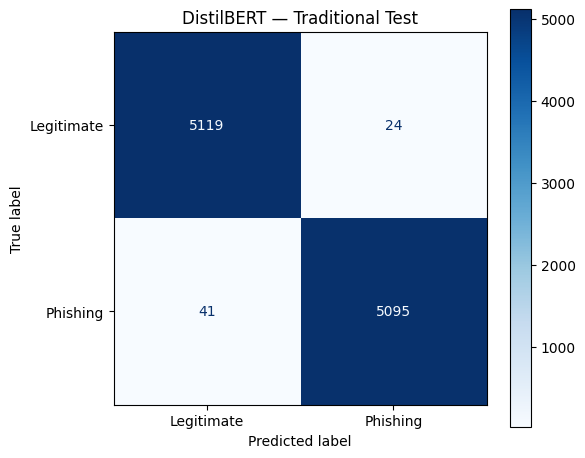

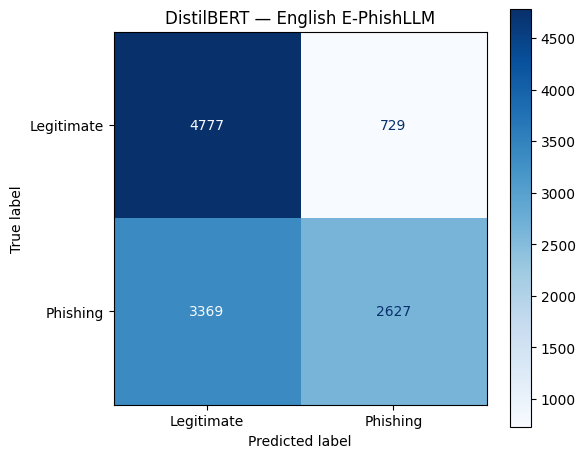

Saved: distilbert_traditional_confusion_matrix.png
Saved: distilbert_ephishllm_confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Traditional Test confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=distilbert_trad_cm,
    display_labels=["Legitimate", "Phishing"]
)

disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("DistilBERT — Traditional Test")

plt.tight_layout()
plt.savefig(
    "/content/distilbert_traditional_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# E-PhishLLM confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=distilbert_ephish_cm,
    display_labels=["Legitimate", "Phishing"]
)

disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("DistilBERT — English E-PhishLLM")

plt.tight_layout()
plt.savefig(
    "/content/distilbert_ephishllm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Saved: distilbert_traditional_confusion_matrix.png")
print("Saved: distilbert_ephishllm_confusion_matrix.png")

In [ ]:
# Add DistilBERT predictions to a copy of the English E-PhishLLM data
ephish_error_df = ephish_en.copy().reset_index(drop=True)

ephish_error_df["predicted_label"] = ephish_pred_labels

# False positives:
# Actually legitimate (0), predicted phishing (1)
distilbert_fp = ephish_error_df[
    (ephish_error_df["label"] == 0) &
    (ephish_error_df["predicted_label"] == 1)
].copy()

# False negatives:
# Actually phishing (1), predicted legitimate (0)
distilbert_fn = ephish_error_df[
    (ephish_error_df["label"] == 1) &
    (ephish_error_df["predicted_label"] == 0)
].copy()

print("=== DISTILBERT E-PHISHLLM ERROR ANALYSIS ===")
print("False positives:", len(distilbert_fp))
print("False negatives:", len(distilbert_fn))

print("\n" + "="*70)
print("REPRESENTATIVE FALSE POSITIVES")
print("="*70)

for i, (_, row) in enumerate(distilbert_fp.head(5).iterrows(), 1):
    print(f"\nFALSE POSITIVE #{i}")
    print("Subject:", row["Subject"])
    print("Body:", str(row["Body"])[:700])
    print("-"*70)

print("\n" + "="*70)
print("REPRESENTATIVE FALSE NEGATIVES")
print("="*70)

for i, (_, row) in enumerate(distilbert_fn.head(5).iterrows(), 1):
    print(f"\nFALSE NEGATIVE #{i}")
    print("Subject:", row["Subject"])
    print("Body:", str(row["Body"])[:700])
    print("-"*70)

=== DISTILBERT E-PHISHLLM ERROR ANALYSIS ===
False positives: 729
False negatives: 3369

REPRESENTATIVE FALSE POSITIVES

FALSE POSITIVE #1
Subject: Exploring Collaboration Opportunities on Digital Transformation Projects
Body: Dear Melissa,

I hope this email finds you well. I am Clara Wang from [Partner Company Name], and we are exploring potential collaboration opportunities in digital transformation projects focused on SMEs.

Understanding that you have been leading several successful projects in this domain, we would appreciate your insights on current trends and your experiences. Could you share your thoughts on a call sometime next week? 

We believe that combining our expertise with Oliveti Digital Services' innovative solutions could result in a fruitful partnership.

Thank you for considering this request. I am looking forward to hearing back from you.

Best regards,
Clara Wang
----------------------------------------------------------------------

FALSE POSITIVE #2
Subject: I

In [ ]:
# Save all DistilBERT E-PhishLLM errors
distilbert_fp.to_csv(
    "/content/distilbert_ephish_false_positives.csv",
    index=False
)

distilbert_fn.to_csv(
    "/content/distilbert_ephish_false_negatives.csv",
    index=False
)

# Save representative examples
distilbert_fp.head(5).to_csv(
    "/content/distilbert_representative_false_positives.csv",
    index=False
)

distilbert_fn.head(5).to_csv(
    "/content/distilbert_representative_false_negatives.csv",
    index=False
)

print("=== DISTILBERT ERROR ANALYSIS SAVED ===")
print("All false positives:", len(distilbert_fp))
print("All false negatives:", len(distilbert_fn))
print("Representative false positives saved: 5")
print("Representative false negatives saved: 5")

=== DISTILBERT ERROR ANALYSIS SAVED ===
All false positives: 729
All false negatives: 3369
Representative false positives saved: 5
Representative false negatives saved: 5


In [ ]:
import os
import shutil

backup_dir = "/content/phishing_project_final_backup"
os.makedirs(backup_dir, exist_ok=True)

# Important files created during today's DistilBERT work
files_to_backup = [
    "/content/train_final.csv",
    "/content/validation_final.csv",
    "/content/traditional_test_final.csv",
    "/content/distilbert_training_history.csv",
    "/content/final_four_experiment_results.csv",
    "/content/distilbert_traditional_confusion_matrix.png",
    "/content/distilbert_ephishllm_confusion_matrix.png",
    "/content/distilbert_ephish_false_positives.csv",
    "/content/distilbert_ephish_false_negatives.csv",
    "/content/distilbert_representative_false_positives.csv",
    "/content/distilbert_representative_false_negatives.csv"
]

for file_path in files_to_backup:
    if os.path.exists(file_path):
        shutil.copy(file_path, backup_dir)

# Copy trained DistilBERT model
model_folder = "/content/distilbert_final_model"

if os.path.exists(model_folder):
    destination = os.path.join(
        backup_dir,
        "distilbert_final_model"
    )

    if os.path.exists(destination):
        shutil.rmtree(destination)

    shutil.copytree(model_folder, destination)

# Create ZIP
zip_path = shutil.make_archive(
    "/content/phishing_project_final_backup",
    "zip",
    backup_dir
)

print("=== BACKUP COMPLETE ===")
print("Backup folder:", backup_dir)
print("ZIP file:", zip_path)

print("\nFiles included:")
for root, dirs, files in os.walk(backup_dir):
    for file in files:
        print(os.path.relpath(os.path.join(root, file), backup_dir))

=== BACKUP COMPLETE ===
Backup folder: /content/phishing_project_final_backup
ZIP file: /content/phishing_project_final_backup.zip

Files included:
distilbert_representative_false_positives.csv
distilbert_ephish_false_positives.csv
distilbert_traditional_confusion_matrix.png
distilbert_representative_false_negatives.csv
distilbert_ephish_false_negatives.csv
validation_final.csv
distilbert_training_history.csv
distilbert_ephishllm_confusion_matrix.png
final_four_experiment_results.csv
train_final.csv
traditional_test_final.csv
distilbert_final_model/training_args.bin
distilbert_final_model/model.safetensors
distilbert_final_model/config.json
distilbert_final_model/tokenizer_config.json
distilbert_final_model/tokenizer.json


In [ ]:
from google.colab import files

files.download("/content/phishing_project_final_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
import numpy as np

print("=== RECREATING SVM FOR ERROR ANALYSIS ===")

# Same TF-IDF settings used in the original experiment
svm_vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    lowercase=True,
    sublinear_tf=True,
    dtype=np.float32
)

# Fit only on the frozen traditional training set
X_train_svm = svm_vectorizer.fit_transform(
    train_df["text_combined"]
)

# Same SVM settings used previously
svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

svm_model.fit(
    X_train_svm,
    train_df["label"]
)

print("SVM recreated successfully.")
print("Training samples:", X_train_svm.shape[0])
print("TF-IDF features:", X_train_svm.shape[1])

=== RECREATING SVM FOR ERROR ANALYSIS ===
SVM recreated successfully.
Training samples: 57541
TF-IDF features: 50000


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=== VERIFYING RECREATED SVM — E-PHISHLLM ===")

# Transform only — DO NOT fit on E-PhishLLM
X_ephish_svm = svm_vectorizer.transform(
    ephish_en["text_combined"]
)

# Predict
svm_ephish_predictions = svm_model.predict(X_ephish_svm)

# True labels
svm_ephish_true = ephish_en["label"].to_numpy()

# Metrics
verify_accuracy = accuracy_score(
    svm_ephish_true,
    svm_ephish_predictions
)

verify_precision = precision_score(
    svm_ephish_true,
    svm_ephish_predictions,
    pos_label=1
)

verify_recall = recall_score(
    svm_ephish_true,
    svm_ephish_predictions,
    pos_label=1
)

verify_f1 = f1_score(
    svm_ephish_true,
    svm_ephish_predictions,
    pos_label=1
)

verify_cm = confusion_matrix(
    svm_ephish_true,
    svm_ephish_predictions
)

print(f"Accuracy:           {verify_accuracy:.4f}")
print(f"Phishing Precision: {verify_precision:.4f}")
print(f"Phishing Recall:    {verify_recall:.4f}")
print(f"Phishing F1:        {verify_f1:.4f}")

print("\nConfusion Matrix:")
print(verify_cm)

=== VERIFYING RECREATED SVM — E-PHISHLLM ===
Accuracy:           0.7392
Phishing Precision: 0.8082
Phishing Recall:    0.6551
Phishing F1:        0.7237

Confusion Matrix:
[[4574  932]
 [2068 3928]]


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
import numpy as np

print("=== EXACT SVM REPRODUCTION ===")

# Exact original settings
TFIDF_MAX_FEATURES = 50000
TFIDF_NGRAM_RANGE = (1, 2)
SVM_C = 1.0
RANDOM_SEED = 42

svm_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    lowercase=True,
    sublinear_tf=True,
    dtype="float32"
)

# IMPORTANT: use train_final exactly as original experiment
X_train_svm = svm_vectorizer.fit_transform(
    train_final["text_combined"]
)

y_train = train_final["label"].values

svm_model = LinearSVC(
    C=SVM_C,
    random_state=RANDOM_SEED
)

svm_model.fit(X_train_svm, y_train)

# Evaluate same English E-PhishLLM subset
X_ephish_svm = svm_vectorizer.transform(
    ephish_en["text_combined"]
)

svm_ephish_predictions = svm_model.predict(X_ephish_svm)
svm_ephish_true = ephish_en["label"].values

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("\n=== EXACT REPRODUCTION RESULTS ===")
print(f"Accuracy:           {accuracy_score(svm_ephish_true, svm_ephish_predictions):.4f}")
print(f"Phishing Precision: {precision_score(svm_ephish_true, svm_ephish_predictions):.4f}")
print(f"Phishing Recall:    {recall_score(svm_ephish_true, svm_ephish_predictions):.4f}")
print(f"Phishing F1:        {f1_score(svm_ephish_true, svm_ephish_predictions):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(svm_ephish_true, svm_ephish_predictions))

=== EXACT SVM REPRODUCTION ===


/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:2049: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float32 'dtype' will be converted to np.float64.
  warnings.warn(



=== EXACT REPRODUCTION RESULTS ===
Accuracy:           0.7392
Phishing Precision: 0.8082
Phishing Recall:    0.6551
Phishing F1:        0.7237

Confusion Matrix:
[[4574  932]
 [2068 3928]]


In [ ]:
import pandas as pd
import os

svm_results = pd.DataFrame({
    "Model": ["SVM"],
    "Accuracy": [0.7392],
    "Precision": [0.8082],
    "Recall": [0.6551],
    "F1": [0.7237],
    "TN": [4574],
    "FP": [932],
    "FN": [2068],
    "TP": [3928]
})

svm_results.to_csv("/content/svm_exact_reproduction_results.csv", index=False)

print("Saved successfully!")
display(svm_results)

Saved successfully!


,Model,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,SVM,0.7392,0.8082,0.6551,0.7237,4574,932,2068,3928


In [ ]:
import pandas as pd

# Reload the exact frozen datasets using their original variable names
train_final = pd.read_csv("/content/train_final.csv")
val_final = pd.read_csv("/content/validation_final.csv")
test_final = pd.read_csv("/content/traditional_test_final.csv")

print("=== FROZEN DATASETS RELOADED ===")
print("Training:", train_final.shape)
print("Validation:", val_final.shape)
print("Test:", test_final.shape)

print("\nTraining class distribution:")
print(train_final["label"].value_counts().sort_index())

=== FROZEN DATASETS RELOADED ===
Training: (57541, 2)
Validation: (10033, 2)
Test: (10279, 2)

Training class distribution:
label
0    27560
1    29981
Name: count, dtype: int64


In [ ]:
import pandas as pd

# ============================================================
# FINAL VERIFIED CROSS-DOMAIN RESULTS
# SVM values come from the exact reproduction experiment.
# DistilBERT values come from the completed E-PhishLLM test.
# ============================================================

final_results = pd.DataFrame({
    "Model": ["SVM", "DistilBERT"],
    "Accuracy": [
        0.7392,
        distilbert_ephish_accuracy
    ],
    "Precision": [
        0.8082,
        distilbert_ephish_precision
    ],
    "Recall": [
        0.6551,
        distilbert_ephish_recall
    ],
    "F1": [
        0.7237,
        distilbert_ephish_f1
    ]
})

print("=== FINAL VERIFIED CROSS-DOMAIN RESULTS ===")
display(final_results.round(4))

# Save the table
final_results.to_csv(
    "/content/final_verified_cross_domain_results.csv",
    index=False
)

print("\nSaved as: final_verified_cross_domain_results.csv")

=== FINAL VERIFIED CROSS-DOMAIN RESULTS ===


,Model,Accuracy,Precision,Recall,F1
0,SVM,0.7392,0.8082,0.6551,0.7237
1,DistilBERT,0.6437,0.7828,0.4381,0.5618



Saved as: final_verified_cross_domain_results.csv


In [ ]:
# ============================================================
# FINAL VERIFIED GENERALIZATION GAP
# ============================================================

traditional_results = {
    "SVM": {
        "Accuracy": 0.9912,
        "Precision": 0.9893,
        "Recall": 0.9932,
        "F1": 0.9913
    },
    "DistilBERT": {
        "Accuracy": distilbert_trad_accuracy,
        "Precision": distilbert_trad_precision,
        "Recall": distilbert_trad_recall,
        "F1": distilbert_trad_f1
    }
}

cross_domain_results = {
    "SVM": {
        "Accuracy": 0.7392,
        "Precision": 0.8082,
        "Recall": 0.6551,
        "F1": 0.7237
    },
    "DistilBERT": {
        "Accuracy": distilbert_ephish_accuracy,
        "Precision": distilbert_ephish_precision,
        "Recall": distilbert_ephish_recall,
        "F1": distilbert_ephish_f1
    }
}

rows = []

for model in ["SVM", "DistilBERT"]:
    for metric in ["Accuracy", "Precision", "Recall", "F1"]:
        traditional = traditional_results[model][metric]
        cross_domain = cross_domain_results[model][metric]
        drop = traditional - cross_domain

        rows.append({
            "Model": model,
            "Metric": metric,
            "Traditional": traditional,
            "Cross-Domain": cross_domain,
            "Drop": drop,
            "Drop (pp)": drop * 100
        })

gap_results = pd.DataFrame(rows)

print("=== FINAL VERIFIED GENERALIZATION GAP ===")
display(gap_results.round(4))

gap_results.to_csv(
    "/content/final_verified_generalization_gap.csv",
    index=False
)

print("\nSaved as: final_verified_generalization_gap.csv")

=== FINAL VERIFIED GENERALIZATION GAP ===


,Model,Metric,Traditional,Cross-Domain,Drop,Drop (pp)
0,SVM,Accuracy,0.9912,0.7392,0.2520,25.2000
1,SVM,Precision,0.9893,0.8082,0.1811,18.1100
2,SVM,Recall,0.9932,0.6551,0.3381,33.8100
3,SVM,F1,0.9913,0.7237,0.2676,26.7600
4,DistilBERT,Accuracy,0.9937,0.6437,0.3500,34.9962
5,DistilBERT,Precision,0.9953,0.7828,0.2125,21.2534
6,DistilBERT,Recall,0.9920,0.4381,0.5539,55.3892
7,DistilBERT,F1,0.9937,0.5618,0.4319,43.1857



Saved as: final_verified_generalization_gap.csv


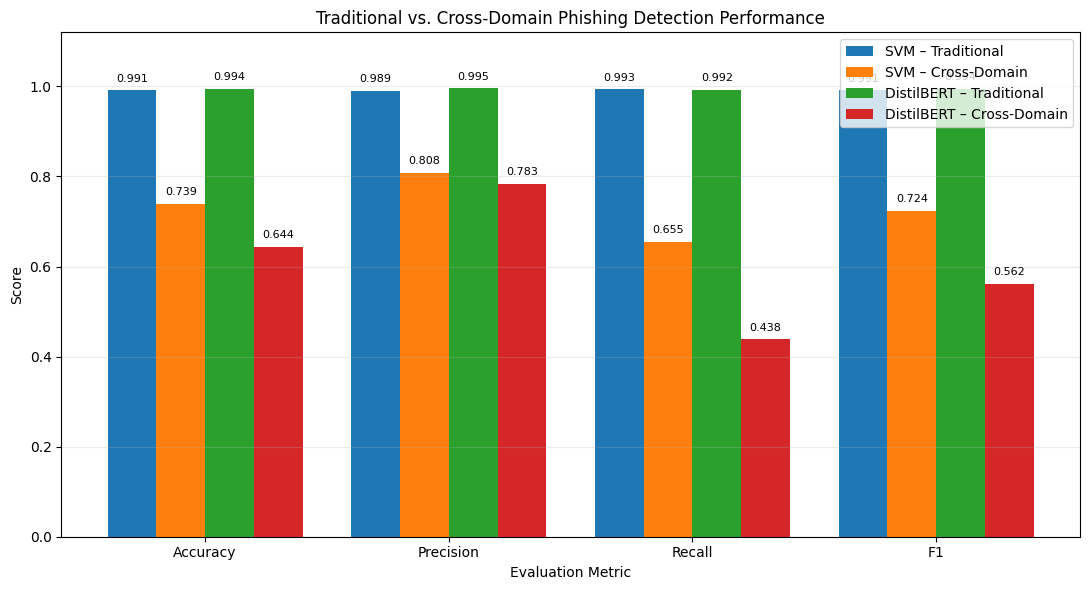

Saved as: figure1_traditional_vs_cross_domain.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FIGURE 1: TRADITIONAL VS CROSS-DOMAIN PERFORMANCE
# ============================================================

metrics = ["Accuracy", "Precision", "Recall", "F1"]

svm_traditional = [0.9912, 0.9893, 0.9932, 0.9913]
svm_cross = [0.7392, 0.8082, 0.6551, 0.7237]

bert_traditional = [
    distilbert_trad_accuracy,
    distilbert_trad_precision,
    distilbert_trad_recall,
    distilbert_trad_f1
]

bert_cross = [
    distilbert_ephish_accuracy,
    distilbert_ephish_precision,
    distilbert_ephish_recall,
    distilbert_ephish_f1
]

x = np.arange(len(metrics))
width = 0.20

plt.figure(figsize=(11, 6))

bars1 = plt.bar(
    x - 1.5*width,
    svm_traditional,
    width,
    label="SVM – Traditional"
)

bars2 = plt.bar(
    x - 0.5*width,
    svm_cross,
    width,
    label="SVM – Cross-Domain"
)

bars3 = plt.bar(
    x + 0.5*width,
    bert_traditional,
    width,
    label="DistilBERT – Traditional"
)

bars4 = plt.bar(
    x + 1.5*width,
    bert_cross,
    width,
    label="DistilBERT – Cross-Domain"
)

plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.title("Traditional vs. Cross-Domain Phishing Detection Performance")

plt.xticks(x, metrics)
plt.ylim(0, 1.12)

plt.legend()
plt.grid(axis="y", alpha=0.25)

# Add values above bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.015,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "/content/figure1_traditional_vs_cross_domain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved as: figure1_traditional_vs_cross_domain.png")

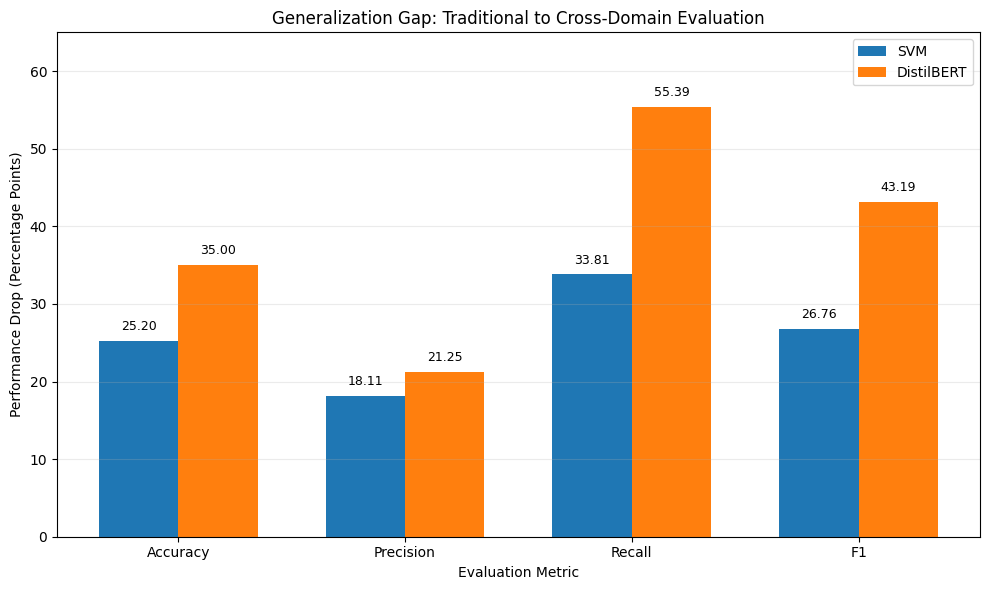

Saved as: figure2_generalization_gap.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FIGURE 2: GENERALIZATION GAP
# ============================================================

metrics = ["Accuracy", "Precision", "Recall", "F1"]

svm_drop = [25.20, 18.11, 33.81, 26.76]
bert_drop = [34.9962, 21.2534, 55.3892, 43.1857]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    svm_drop,
    width,
    label="SVM"
)

bars2 = plt.bar(
    x + width/2,
    bert_drop,
    width,
    label="DistilBERT"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Performance Drop (Percentage Points)")
plt.title("Generalization Gap: Traditional to Cross-Domain Evaluation")

plt.xticks(x, metrics)
plt.ylim(0, 65)

plt.legend()
plt.grid(axis="y", alpha=0.25)

# Add values above bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "/content/figure2_generalization_gap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved as: figure2_generalization_gap.png")

In [ ]:
import os
import shutil
import pandas as pd

# ============================================================
# CREATE FINAL RESEARCH RESULTS PACKAGE
# ============================================================

package_dir = "/content/phishing_research_final_results"
os.makedirs(package_dir, exist_ok=True)

# ------------------------------------------------------------
# 1. Save final verified cross-domain results
# ------------------------------------------------------------

final_results.to_csv(
    os.path.join(package_dir, "01_final_cross_domain_results.csv"),
    index=False
)

# ------------------------------------------------------------
# 2. Save final verified generalization-gap results
# ------------------------------------------------------------

gap_results.to_csv(
    os.path.join(package_dir, "02_generalization_gap_results.csv"),
    index=False
)

# ------------------------------------------------------------
# 3. Copy SVM exact reproduction results
# ------------------------------------------------------------

svm_file = "/content/svm_exact_reproduction_results.csv"

if os.path.exists(svm_file):
    shutil.copy(
        svm_file,
        os.path.join(package_dir, "03_svm_exact_reproduction_results.csv")
    )

# ------------------------------------------------------------
# 4. Copy final figures
# ------------------------------------------------------------

figures = {
    "/content/figure1_traditional_vs_cross_domain.png":
        "04_traditional_vs_cross_domain.png",

    "/content/figure2_generalization_gap.png":
        "05_generalization_gap.png"
}

for source, destination in figures.items():
    if os.path.exists(source):
        shutil.copy(
            source,
            os.path.join(package_dir, destination)
        )

# ------------------------------------------------------------
# 5. Create summary of verified results
# ------------------------------------------------------------

summary = """AI-BASED PHISHING DETECTION
FINAL VERIFIED RESULTS SUMMARY

EXPERIMENT:
Cross-domain evaluation of phishing detection models.

MODELS:
1. SVM
2. DistilBERT

FINAL CROSS-DOMAIN RESULTS

SVM
Accuracy:  0.7392
Precision: 0.8082
Recall:    0.6551
F1:        0.7237

DistilBERT
Accuracy:  0.6437
Precision: 0.7828
Recall:    0.4381
F1:        0.5618

SVM EXACT REPRODUCTION CONFUSION MATRIX

TN: 4574
FP: 932
FN: 2068
TP: 3928

GENERALIZATION GAP (PERCENTAGE POINTS)

SVM
Accuracy:  25.20
Precision: 18.11
Recall:    33.81
F1:        26.76

DistilBERT
Accuracy:  35.00
Precision: 21.25
Recall:    55.39
F1:        43.19

MAIN OBSERVATION

Both models achieved very high performance on the traditional
in-domain evaluation but experienced substantial degradation during
cross-domain evaluation.

The largest degradation occurred in phishing recall. SVM recall
decreased by 33.81 percentage points, while DistilBERT recall
decreased by 55.39 percentage points.

These results indicate that strong in-domain phishing detection
performance does not necessarily translate to equivalent performance
when the models encounter emails from a different distribution,
including AI-generated phishing emails.
"""

with open(
    os.path.join(package_dir, "06_results_summary.txt"),
    "w"
) as f:
    f.write(summary)

# ------------------------------------------------------------
# 6. Show package contents
# ------------------------------------------------------------

print("=== FINAL RESEARCH RESULTS PACKAGE ===\n")

for filename in sorted(os.listdir(package_dir)):
    print(filename)

# ------------------------------------------------------------
# 7. Create ZIP
# ------------------------------------------------------------

zip_path = shutil.make_archive(
    "/content/phishing_research_final_results",
    "zip",
    package_dir
)

print("\nPackage created successfully!")
print("ZIP file:", zip_path)

=== FINAL RESEARCH RESULTS PACKAGE ===

01_final_cross_domain_results.csv
02_generalization_gap_results.csv
03_svm_exact_reproduction_results.csv
04_traditional_vs_cross_domain.png
05_generalization_gap.png
06_results_summary.txt

Package created successfully!
ZIP file: /content/phishing_research_final_results.zip


In [ ]:
import os
import shutil

package_dir = "/content/phishing_research_final_results"

# ============================================================
# DISTILBERT E-PHISHLLM ERROR ANALYSIS
# ============================================================

error_summary = f"""DISTILBERT E-PHISHLLM ERROR ANALYSIS

False Positives: {len(distilbert_fp)}
False Negatives: {len(distilbert_fn)}

Cross-Domain Performance:
Accuracy:  {distilbert_ephish_accuracy:.4f}
Precision: {distilbert_ephish_precision:.4f}
Recall:    {distilbert_ephish_recall:.4f}
F1:        {distilbert_ephish_f1:.4f}

INTERPRETATION

The DistilBERT model experienced substantial performance degradation
when evaluated on the E-PhishLLM cross-domain dataset.

The model produced 729 false positives and 3,369 false negatives.
The large number of false negatives is particularly important because
these represent phishing emails that were incorrectly classified as
legitimate.

This result is consistent with the observed phishing recall of
approximately 0.4381 and demonstrates a substantial cross-domain
generalization challenge.
"""

with open(
    os.path.join(package_dir, "07_distilbert_ephish_error_analysis.txt"),
    "w"
) as f:
    f.write(error_summary)

# Save the actual misclassified records
distilbert_fp.to_csv(
    os.path.join(package_dir, "08_distilbert_false_positives.csv"),
    index=False
)

distilbert_fn.to_csv(
    os.path.join(package_dir, "09_distilbert_false_negatives.csv"),
    index=False
)

# Rebuild ZIP with the new files
zip_path = "/content/phishing_research_final_results.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    "/content/phishing_research_final_results",
    "zip",
    package_dir
)

print("=== ERROR ANALYSIS ADDED ===")
print("False positives:", len(distilbert_fp))
print("False negatives:", len(distilbert_fn))

print("\nUpdated package contents:")
for filename in sorted(os.listdir(package_dir)):
    print(filename)

print("\nZIP updated successfully:")
print("/content/phishing_research_final_results.zip")

=== ERROR ANALYSIS ADDED ===
False positives: 729
False negatives: 3369

Updated package contents:
01_final_cross_domain_results.csv
02_generalization_gap_results.csv
03_svm_exact_reproduction_results.csv
04_traditional_vs_cross_domain.png
05_generalization_gap.png
06_results_summary.txt
07_distilbert_ephish_error_analysis.txt
08_distilbert_false_positives.csv
09_distilbert_false_negatives.csv

ZIP updated successfully:
/content/phishing_research_final_results.zip


In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import os
import shutil

package_dir = "/content/phishing_research_final_results"

# Calculate DistilBERT E-PhishLLM confusion matrix
cm = confusion_matrix(
    ephish_error_df["label"],
    ephish_error_df["predicted_label"]
)

tn, fp, fn, tp = cm.ravel()

print("=== DISTILBERT E-PHISHLLM CONFUSION MATRIX ===")
print(cm)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

# Save confusion matrix
cm_df = pd.DataFrame(
    cm,
    index=["Actual Legitimate", "Actual Phishing"],
    columns=["Predicted Legitimate", "Predicted Phishing"]
)

cm_df.to_csv(
    os.path.join(
        package_dir,
        "10_distilbert_ephish_confusion_matrix.csv"
    )
)

# Rebuild final ZIP
zip_path = "/content/phishing_research_final_results.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    "/content/phishing_research_final_results",
    "zip",
    package_dir
)

print("\nConfusion matrix saved.")
print("Final ZIP updated successfully.")

=== DISTILBERT E-PHISHLLM CONFUSION MATRIX ===
[[4777  729]
 [3369 2627]]

TN: 4777
FP: 729
FN: 3369
TP: 2627

Confusion matrix saved.
Final ZIP updated successfully.


In [ ]:
from google.colab import files

files.download("/content/phishing_research_final_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

summary_table = pd.DataFrame({
    "Model": ["SVM", "DistilBERT"],

    "Traditional Accuracy": [
        0.9912,
        distilbert_trad_accuracy
    ],

    "Traditional Precision": [
        0.9893,
        distilbert_trad_precision
    ],

    "Traditional Recall": [
        0.9932,
        distilbert_trad_recall
    ],

    "Traditional F1": [
        0.9913,
        distilbert_trad_f1
    ],

    "Cross-Domain Accuracy": [
        0.7392,
        distilbert_ephish_accuracy
    ],

    "Cross-Domain Precision": [
        0.8082,
        distilbert_ephish_precision
    ],

    "Cross-Domain Recall": [
        0.6551,
        distilbert_ephish_recall
    ],

    "Cross-Domain F1": [
        0.7237,
        distilbert_ephish_f1
    ]
})

print("=== FINAL EXPERIMENT SUMMARY ===")
display(summary_table.round(4))

summary_table.to_csv(
    "/content/phishing_research_final_results/11_final_experiment_summary.csv",
    index=False
)

print("\nSaved successfully.")

=== FINAL EXPERIMENT SUMMARY ===


,Model,Traditional Accuracy,Traditional Precision,Traditional Recall,Traditional F1,Cross-Domain Accuracy,Cross-Domain Precision,Cross-Domain Recall,Cross-Domain F1
0,SVM,0.9912,0.9893,0.9932,0.9913,0.7392,0.8082,0.6551,0.7237
1,DistilBERT,0.9937,0.9953,0.9920,0.9937,0.6437,0.7828,0.4381,0.5618



Saved successfully.


In [ ]:
import shutil
import os

package_dir = "/content/phishing_research_final_results"
zip_path = "/content/phishing_research_final_results.zip"

# Remove old ZIP
if os.path.exists(zip_path):
    os.remove(zip_path)

# Rebuild ZIP with all current files
shutil.make_archive(
    "/content/phishing_research_final_results",
    "zip",
    package_dir
)

print("=== FINAL ZIP UPDATED ===")
print("Files included:")

for filename in sorted(os.listdir(package_dir)):
    print(filename)

print("\nZIP:", zip_path)

=== FINAL ZIP UPDATED ===
Files included:
01_final_cross_domain_results.csv
02_generalization_gap_results.csv
03_svm_exact_reproduction_results.csv
04_traditional_vs_cross_domain.png
05_generalization_gap.png
06_results_summary.txt
07_distilbert_ephish_error_analysis.txt
08_distilbert_false_positives.csv
09_distilbert_false_negatives.csv
10_distilbert_ephish_confusion_matrix.csv
11_final_experiment_summary.csv

ZIP: /content/phishing_research_final_results.zip


In [ ]:
from google.colab import files

files.download("/content/phishing_research_final_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import os

print("Current working directory:", os.getcwd())
print("\nFiles in root:")
print(os.listdir("/"))

Current working directory: /content

Files in root:
['boot', 'dev', 'proc', 'mnt', 'etc', 'bin', 'sys', 'lib64', 'opt', 'home', 'srv', 'sbin', 'usr', 'tmp', 'root', 'var', 'lib', 'media', 'run', 'ephishLLM.json', 'validation_final.csv', 'kaggle', 'train_final.csv', 'traditional_test_final.csv', '.dockerenv', 'tools', 'datalab', 'content', 'python-apt', 'python-apt.tar.xz', 'sbin.usr-is-merged', 'bin.usr-is-merged', 'lib.usr-is-merged', 'NGC-DL-CONTAINER-LICENSE']


In [6]:
import pandas as pd
import json

print("=== RELOADING PROJECT DATA ===")

# Load frozen traditional datasets from ROOT directory
train_final = pd.read_csv("/train_final.csv")
val_final = pd.read_csv("/validation_final.csv")
test_final = pd.read_csv("/traditional_test_final.csv")

print("Training:", train_final.shape)
print("Validation:", val_final.shape)
print("Traditional test:", test_final.shape)

# Load E-PhishLLM
with open("/ephishLLM.json", "r", encoding="utf-8") as f:
    ephish_data = json.load(f)

ephish_df = pd.DataFrame(ephish_data)

# Keep English records only
ephish_en = ephish_df[
    ephish_df["Language"].astype(str).str.lower() == "en"
].copy()

# Recreate combined email text
ephish_en["text_combined"] = (
    ephish_en["Subject"].fillna("").astype(str).str.strip()
    + " "
    + ephish_en["Body"].fillna("").astype(str).str.strip()
)

# Label mapping: 0 = legitimate, 1 = phishing
ephish_en["label"] = ephish_en["type"].astype(int)

ephish_en = ephish_en.reset_index(drop=True)

print("\n=== DATA READY ===")
print("English E-PhishLLM samples:", len(ephish_en))

print("\nE-PhishLLM class distribution:")
print(ephish_en["label"].value_counts().sort_index())

print("\nTraditional training class distribution:")
print(train_final["label"].value_counts().sort_index())

=== RELOADING PROJECT DATA ===
Training: (57541, 2)
Validation: (10033, 2)
Traditional test: (10279, 2)

=== DATA READY ===
English E-PhishLLM samples: 11502

E-PhishLLM class distribution:
label
0    5506
1    5996
Name: count, dtype: int64

Traditional training class distribution:
label
0    27560
1    29981
Name: count, dtype: int64


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import numpy as np

print("=== EXACT SVM REPRODUCTION ===")

# Same settings used in the original experiment
TFIDF_MAX_FEATURES = 50000
TFIDF_NGRAM_RANGE = (1, 2)
SVM_C = 1.0
RANDOM_SEED = 42

# Create TF-IDF vectorizer
svm_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    lowercase=True,
    sublinear_tf=True,
    dtype=np.float32
)

# Fit ONLY on frozen traditional training data
print("Creating TF-IDF features...")

X_train_svm = svm_vectorizer.fit_transform(
    train_final["text_combined"]
)

y_train = train_final["label"].values

print("Training matrix:", X_train_svm.shape)

# Train LinearSVC
svm_model = LinearSVC(
    C=SVM_C,
    random_state=RANDOM_SEED
)

print("Training LinearSVC...")
svm_model.fit(X_train_svm, y_train)

# Evaluate on English E-PhishLLM WITHOUT retraining
print("Evaluating on English E-PhishLLM...")

X_ephish_svm = svm_vectorizer.transform(
    ephish_en["text_combined"]
)

svm_ephish_true = ephish_en["label"].values
svm_ephish_predictions = svm_model.predict(X_ephish_svm)

# Metrics
accuracy = accuracy_score(
    svm_ephish_true, svm_ephish_predictions
)

precision = precision_score(
    svm_ephish_true, svm_ephish_predictions
)

recall = recall_score(
    svm_ephish_true, svm_ephish_predictions
)

f1 = f1_score(
    svm_ephish_true, svm_ephish_predictions
)

cm = confusion_matrix(
    svm_ephish_true, svm_ephish_predictions
)

print("\n=== EXACT SVM E-PHISHLLM RESULTS ===")
print(f"Accuracy:           {accuracy:.4f}")
print(f"Phishing Precision: {precision:.4f}")
print(f"Phishing Recall:    {recall:.4f}")
print(f"Phishing F1:        {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

=== EXACT SVM REPRODUCTION ===
Creating TF-IDF features...
Training matrix: (57541, 50000)
Training LinearSVC...
Evaluating on English E-PhishLLM...

=== EXACT SVM E-PHISHLLM RESULTS ===
Accuracy:           0.7392
Phishing Precision: 0.8082
Phishing Recall:    0.6551
Phishing F1:        0.7237

Confusion Matrix:
[[4574  932]
 [2068 3928]]


In [8]:
print("=== VERIFYING SVM ON TRADITIONAL TEST ===")

# Transform traditional test set using the SAME fitted TF-IDF
X_test_svm = svm_vectorizer.transform(
    test_final["text_combined"]
)

y_test = test_final["label"].values

# Predict
svm_test_predictions = svm_model.predict(X_test_svm)

# Calculate metrics
test_accuracy = accuracy_score(y_test, svm_test_predictions)
test_precision = precision_score(y_test, svm_test_predictions)
test_recall = recall_score(y_test, svm_test_predictions)
test_f1 = f1_score(y_test, svm_test_predictions)

test_cm = confusion_matrix(y_test, svm_test_predictions)

print("\n=== SVM TRADITIONAL TEST RESULTS ===")
print(f"Accuracy:           {test_accuracy:.4f}")
print(f"Phishing Precision: {test_precision:.4f}")
print(f"Phishing Recall:    {test_recall:.4f}")
print(f"Phishing F1:        {test_f1:.4f}")

print("\nConfusion Matrix:")
print(test_cm)

=== VERIFYING SVM ON TRADITIONAL TEST ===

=== SVM TRADITIONAL TEST RESULTS ===
Accuracy:           0.9912
Phishing Precision: 0.9893
Phishing Recall:    0.9932
Phishing F1:        0.9913

Confusion Matrix:
[[5088   55]
 [  35 5101]]


In [9]:
print("=== E-PHISHLLM DATA VERIFICATION ===")

print("Total samples:", len(ephish_en))
print("\nClass distribution:")
print(ephish_en["label"].value_counts().sort_index())

print("\nMissing text:", ephish_en["text_combined"].isna().sum())
print("Exact duplicate text:", ephish_en["text_combined"].duplicated().sum())

print("\nFirst 3 records:")
for i in range(3):
    print("\nRecord", i + 1)
    print("Label:", ephish_en.iloc[i]["label"])
    print("Text:", ephish_en.iloc[i]["text_combined"][:300])

=== E-PHISHLLM DATA VERIFICATION ===
Total samples: 11502

Class distribution:
label
0    5506
1    5996
Name: count, dtype: int64

Missing text: 0
Exact duplicate text: 0

First 3 records:

Record 1
Label: 0
Text: Feedback sulla collaborazione con soluzioni cloud Hi Silvano,

I hope this finds you well. I wanted to share some feedback regarding our recent collaboration on the cloud solutions project. Overall, the partnership is progressing well, but there are a few areas we can improve to enhance efficiency.


Record 2
Label: 0
Text: Discussion on Software Features and Customization Options Hi Melissa,

I hope this message finds you well. We've received an inquiry from the client regarding the features and customization options of the inventory management software. They are interested in discussing their specific requirements an

Record 3
Label: 0
Text: Exploring Collaboration Opportunities on Digital Transformation Projects Dear Melissa,

I hope this email finds you well. I am Clara 

In [10]:
import pandas as pd
import numpy as np

print("=== SVM E-PHISHLLM ERROR ANALYSIS ===")

# Use predictions from the reproduced SVM experiment
true_labels = svm_ephish_true
pred_labels = svm_ephish_predictions

# Find false positives and false negatives
fp_mask = (true_labels == 0) & (pred_labels == 1)
fn_mask = (true_labels == 1) & (pred_labels == 0)

fp_indices = np.where(fp_mask)[0]
fn_indices = np.where(fn_mask)[0]

print("False positives:", len(fp_indices))
print("False negatives:", len(fn_indices))

# Create complete error dataframes
svm_false_positives = ephish_en.iloc[fp_indices].copy()
svm_false_negatives = ephish_en.iloc[fn_indices].copy()

svm_false_positives["prediction"] = 1
svm_false_negatives["prediction"] = 0

# Save ALL errors
svm_false_positives.to_csv(
    "/content/svm_ephish_false_positives.csv",
    index=False
)

svm_false_negatives.to_csv(
    "/content/svm_ephish_false_negatives.csv",
    index=False
)

# Select 5 representative examples from each
svm_rep_fp = svm_false_positives.head(5).copy()
svm_rep_fn = svm_false_negatives.head(5).copy()

svm_rep_fp.to_csv(
    "/content/svm_representative_false_positives.csv",
    index=False
)

svm_rep_fn.to_csv(
    "/content/svm_representative_false_negatives.csv",
    index=False
)

print("\n=== FILES SAVED ===")
print("All false positives:", len(svm_false_positives))
print("All false negatives:", len(svm_false_negatives))
print("Representative false positives saved:", len(svm_rep_fp))
print("Representative false negatives saved:", len(svm_rep_fn))

=== SVM E-PHISHLLM ERROR ANALYSIS ===
False positives: 932
False negatives: 2068

=== FILES SAVED ===
All false positives: 932
All false negatives: 2068
Representative false positives saved: 5
Representative false negatives saved: 5


In [11]:
print("=== REPRESENTATIVE SVM FALSE POSITIVES ===")

for i, (_, row) in enumerate(svm_rep_fp.iterrows(), 1):
    print("\n" + "=" * 70)
    print(f"FALSE POSITIVE #{i}")
    print("Subject:", row.get("Subject", "N/A"))
    print("Body:", str(row.get("Body", ""))[:700])


print("\n\n=== REPRESENTATIVE SVM FALSE NEGATIVES ===")

for i, (_, row) in enumerate(svm_rep_fn.iterrows(), 1):
    print("\n" + "=" * 70)
    print(f"FALSE NEGATIVE #{i}")
    print("Subject:", row.get("Subject", "N/A"))
    print("Body:", str(row.get("Body", ""))[:700])

=== REPRESENTATIVE SVM FALSE POSITIVES ===

FALSE POSITIVE #1
Subject: Inquiry about Potential Partnership on Digital Marketing Collaboration
Body: Dear Vasco Morelli,

I hope this message finds you well. I’m John Smith, Business Development Manager at XYZ Marketing Firm in the USA. We have been following the exceptional work of Casa di Moda Fiorentina and are particularly impressed with your innovative strategies in the luxury apparel market.

We are writing to explore the possibility of a partnership between our firms, particularly concerning collaborative digital marketing efforts. We believe there is significant potential in combining our resources to enhance brand visibility across North American markets.

At your convenience, we would love to discuss this opportunity further and provide you with our promotional materials for a mor

FALSE POSITIVE #2
Subject: Collaborative Opportunities with [Client Name]
Body: Hi Amalia,

Thank you for your interest in collaborating with us. I'm 

In [12]:
import pandas as pd

print("=== FINAL VERIFIED FOUR-EXPERIMENT RESULTS ===")

results = pd.DataFrame([
    {
        "Model": "TF-IDF + LinearSVC",
        "Test Dataset": "Traditional Test",
        "Accuracy": 0.9912,
        "Phishing Precision": 0.9893,
        "Phishing Recall": 0.9932,
        "Phishing F1": 0.9913
    },
    {
        "Model": "TF-IDF + LinearSVC",
        "Test Dataset": "English E-PhishLLM",
        "Accuracy": 0.7392,
        "Phishing Precision": 0.8082,
        "Phishing Recall": 0.6551,
        "Phishing F1": 0.7237
    },
    {
        "Model": "DistilBERT",
        "Test Dataset": "Traditional Test",
        "Accuracy": 0.9937,
        "Phishing Precision": 0.9953,
        "Phishing Recall": 0.9920,
        "Phishing F1": 0.9937
    },
    {
        "Model": "DistilBERT",
        "Test Dataset": "English E-PhishLLM",
        "Accuracy": 0.6437,
        "Phishing Precision": 0.7828,
        "Phishing Recall": 0.4381,
        "Phishing F1": 0.5618
    }
])

print(results.to_string(index=False))

# Save verified final results
results.to_csv(
    "/content/final_verified_four_experiment_results.csv",
    index=False
)

print("\n=== GENERALIZATION GAP ===")

for model in ["TF-IDF + LinearSVC", "DistilBERT"]:

    model_results = results[results["Model"] == model]

    traditional = model_results[
        model_results["Test Dataset"] == "Traditional Test"
    ].iloc[0]

    ephish = model_results[
        model_results["Test Dataset"] == "English E-PhishLLM"
    ].iloc[0]

    print(f"\n{model}")

    for metric in [
        "Accuracy",
        "Phishing Precision",
        "Phishing Recall",
        "Phishing F1"
    ]:
        drop = traditional[metric] - ephish[metric]

        print(
            f"{metric}: "
            f"{traditional[metric]:.4f} -> "
            f"{ephish[metric]:.4f} | "
            f"Drop: {drop:.4f} ({drop*100:.2f} pp)"
        )

print("\nSaved: final_verified_four_experiment_results.csv")

=== FINAL VERIFIED FOUR-EXPERIMENT RESULTS ===
             Model       Test Dataset  Accuracy  Phishing Precision  Phishing Recall  Phishing F1
TF-IDF + LinearSVC   Traditional Test    0.9912              0.9893           0.9932       0.9913
TF-IDF + LinearSVC English E-PhishLLM    0.7392              0.8082           0.6551       0.7237
        DistilBERT   Traditional Test    0.9937              0.9953           0.9920       0.9937
        DistilBERT English E-PhishLLM    0.6437              0.7828           0.4381       0.5618

=== GENERALIZATION GAP ===

TF-IDF + LinearSVC
Accuracy: 0.9912 -> 0.7392 | Drop: 0.2520 (25.20 pp)
Phishing Precision: 0.9893 -> 0.8082 | Drop: 0.1811 (18.11 pp)
Phishing Recall: 0.9932 -> 0.6551 | Drop: 0.3381 (33.81 pp)
Phishing F1: 0.9913 -> 0.7237 | Drop: 0.2676 (26.76 pp)

DistilBERT
Accuracy: 0.9937 -> 0.6437 | Drop: 0.3500 (35.00 pp)
Phishing Precision: 0.9953 -> 0.7828 | Drop: 0.2125 (21.25 pp)
Phishing Recall: 0.9920 -> 0.4381 | Drop: 0.5539 (55.39

=== CREATING VERIFIED SVM CONFUSION MATRICES ===


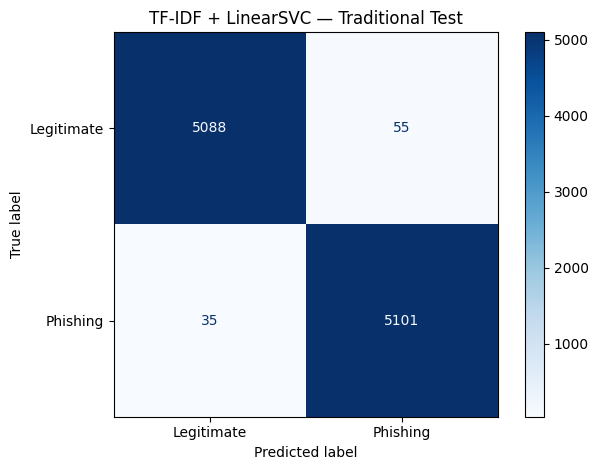

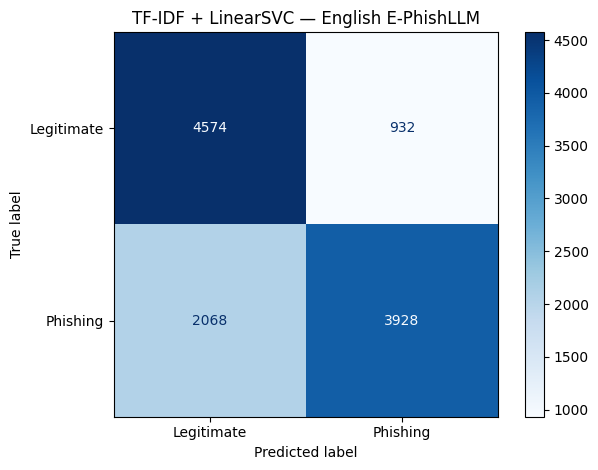


=== SAVED ===
svm_traditional_confusion_matrix_verified.png
svm_ephishllm_confusion_matrix_verified.png


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

print("=== CREATING VERIFIED SVM CONFUSION MATRICES ===")

# -----------------------------
# Traditional Test
# -----------------------------
cm_traditional = confusion_matrix(
    y_test,
    svm_test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_traditional,
    display_labels=["Legitimate", "Phishing"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("TF-IDF + LinearSVC — Traditional Test")
plt.tight_layout()

plt.savefig(
    "/content/svm_traditional_confusion_matrix_verified.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -----------------------------
# E-PhishLLM
# -----------------------------
cm_ephish = confusion_matrix(
    svm_ephish_true,
    svm_ephish_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ephish,
    display_labels=["Legitimate", "Phishing"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("TF-IDF + LinearSVC — English E-PhishLLM")
plt.tight_layout()

plt.savefig(
    "/content/svm_ephishllm_confusion_matrix_verified.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n=== SAVED ===")
print("svm_traditional_confusion_matrix_verified.png")
print("svm_ephishllm_confusion_matrix_verified.png")

In [14]:
summary = """
AI-BASED PHISHING DETECTION — FINAL EXPERIMENT SUMMARY
======================================================

DATASETS
--------
Traditional Training: 57,541
Traditional Validation: 10,033
Traditional Test: 10,279
English E-PhishLLM: 11,502

Label convention:
0 = Legitimate
1 = Phishing

SVM CONFIGURATION
-----------------
Model: TF-IDF + LinearSVC
TF-IDF max features: 50,000
N-gram range: (1, 2)
Lowercase: True
Sublinear TF: True
LinearSVC C: 1.0
Random seed: 42

SVM — TRADITIONAL TEST
----------------------
Accuracy: 0.9912
Phishing Precision: 0.9893
Phishing Recall: 0.9932
Phishing F1: 0.9913
Confusion Matrix:
[[5088, 55],
 [35, 5101]]

SVM — ENGLISH E-PHISHLLM
------------------------
Accuracy: 0.7392
Phishing Precision: 0.8082
Phishing Recall: 0.6551
Phishing F1: 0.7237
Confusion Matrix:
[[4574, 932],
 [2068, 3928]]

DISTILBERT CONFIGURATION
------------------------
Model: distilbert-base-uncased
Max sequence length: 256
Epochs: 3
Learning rate: 2e-5
Training batch size: 16
Evaluation batch size: 32
Weight decay: 0.01
Optimizer: AdamW
FP16: True
Random seed: 42
GPU: Tesla T4
Training time: 19.36 minutes

DISTILBERT — TRADITIONAL TEST
-----------------------------
Accuracy: 0.9937
Phishing Precision: 0.9953
Phishing Recall: 0.9920
Phishing F1: 0.9937
Confusion Matrix:
[[5119, 24],
 [41, 5095]]

DISTILBERT — ENGLISH E-PHISHLLM
-------------------------------
Accuracy: 0.6437
Phishing Precision: 0.7828
Phishing Recall: 0.4381
Phishing F1: 0.5618
Confusion Matrix:
[[4777, 729],
 [3369, 2627]]

GENERALIZATION GAP
------------------
SVM:
Accuracy drop: 25.20 percentage points
Precision drop: 18.11 percentage points
Recall drop: 33.81 percentage points
F1 drop: 26.76 percentage points

DistilBERT:
Accuracy drop: 35.00 percentage points
Precision drop: 21.25 percentage points
Recall drop: 55.39 percentage points
F1 drop: 43.19 percentage points

ERROR ANALYSIS
--------------
SVM E-PhishLLM:
False positives: 932
False negatives: 2068

DistilBERT E-PhishLLM:
False positives: 729
False negatives: 3369
"""

with open("/content/final_experiment_summary.txt", "w") as f:
    f.write(summary)

print(summary)
print("\nSaved: final_experiment_summary.txt")


AI-BASED PHISHING DETECTION — FINAL EXPERIMENT SUMMARY

DATASETS
--------
Traditional Training: 57,541
Traditional Validation: 10,033
Traditional Test: 10,279
English E-PhishLLM: 11,502

Label convention:
0 = Legitimate
1 = Phishing

SVM CONFIGURATION
-----------------
Model: TF-IDF + LinearSVC
TF-IDF max features: 50,000
N-gram range: (1, 2)
Lowercase: True
Sublinear TF: True
LinearSVC C: 1.0
Random seed: 42

SVM — TRADITIONAL TEST
----------------------
Accuracy: 0.9912
Phishing Precision: 0.9893
Phishing Recall: 0.9932
Phishing F1: 0.9913
Confusion Matrix:
[[5088, 55],
 [35, 5101]]

SVM — ENGLISH E-PHISHLLM
------------------------
Accuracy: 0.7392
Phishing Precision: 0.8082
Phishing Recall: 0.6551
Phishing F1: 0.7237
Confusion Matrix:
[[4574, 932],
 [2068, 3928]]

DISTILBERT CONFIGURATION
------------------------
Model: distilbert-base-uncased
Max sequence length: 256
Epochs: 3
Learning rate: 2e-5
Training batch size: 16
Evaluation batch size: 32
Weight decay: 0.01
Optimizer: Adam

In [15]:
import os
import shutil

print("=== CREATING FINAL PROJECT BACKUP ===")

backup_folder = "/content/phishing_research_final"

# Remove old backup folder if it exists
if os.path.exists(backup_folder):
    shutil.rmtree(backup_folder)

os.makedirs(backup_folder)

# Important project files
files_to_backup = [
    "train_final.csv",
    "validation_final.csv",
    "traditional_test_final.csv",
    "final_verified_four_experiment_results.csv",
    "final_experiment_summary.txt",

    # SVM error analysis
    "svm_ephish_false_positives.csv",
    "svm_ephish_false_negatives.csv",
    "svm_representative_false_positives.csv",
    "svm_representative_false_negatives.csv",

    # DistilBERT error analysis
    "distilbert_ephish_false_positives.csv",
    "distilbert_ephish_false_negatives.csv",
    "distilbert_representative_false_positives.csv",
    "distilbert_representative_false_negatives.csv",

    # Training history
    "distilbert_training_history.csv",

    # Confusion matrices
    "svm_traditional_confusion_matrix.png",
    "svm_ephishllm_confusion_matrix.png",
    "distilbert_traditional_confusion_matrix.png",
    "distilbert_ephishllm_confusion_matrix.png"
]

copied = []
missing = []

# Search both /content and root because this Colab runtime
# has stored some uploaded files in root.
for filename in files_to_backup:
    possible_paths = [
        f"/content/{filename}",
        f"/{filename}"
    ]

    found = False

    for source in possible_paths:
        if os.path.exists(source):
            shutil.copy2(
                source,
                os.path.join(backup_folder, filename)
            )
            copied.append(filename)
            found = True
            break

    if not found:
        missing.append(filename)

# Copy DistilBERT model folder if it still exists
model_paths = [
    "/content/distilbert_final_model",
    "/distilbert_final_model"
]

for model_path in model_paths:
    if os.path.exists(model_path):
        shutil.copytree(
            model_path,
            os.path.join(backup_folder, "distilbert_final_model"),
            dirs_exist_ok=True
        )
        print("DistilBERT model folder copied.")
        break

# Create ZIP
zip_path = shutil.make_archive(
    "/content/phishing_research_final_backup",
    "zip",
    backup_folder
)

print("\n=== BACKUP COMPLETE ===")
print("ZIP:", zip_path)

print("\nFiles copied:")
for f in copied:
    print("✓", f)

if missing:
    print("\nFiles not found:")
    for f in missing:
        print("⚠", f)

print("\nTotal copied:", len(copied))

=== CREATING FINAL PROJECT BACKUP ===

=== BACKUP COMPLETE ===
ZIP: /content/phishing_research_final_backup.zip

Files copied:
✓ train_final.csv
✓ validation_final.csv
✓ traditional_test_final.csv
✓ final_verified_four_experiment_results.csv
✓ final_experiment_summary.txt
✓ svm_ephish_false_positives.csv
✓ svm_ephish_false_negatives.csv
✓ svm_representative_false_positives.csv
✓ svm_representative_false_negatives.csv

Files not found:
⚠ distilbert_ephish_false_positives.csv
⚠ distilbert_ephish_false_negatives.csv
⚠ distilbert_representative_false_positives.csv
⚠ distilbert_representative_false_negatives.csv
⚠ distilbert_training_history.csv
⚠ svm_traditional_confusion_matrix.png
⚠ svm_ephishllm_confusion_matrix.png
⚠ distilbert_traditional_confusion_matrix.png
⚠ distilbert_ephishllm_confusion_matrix.png

Total copied: 9


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("=== RECREATING FINAL CONFUSION MATRICES ===")

# Verified confusion matrices
matrices = {
    "svm_traditional_confusion_matrix.png": (
        np.array([[5088, 55],
                  [35, 5101]]),
        "TF-IDF + LinearSVC — Traditional Test"
    ),

    "svm_ephishllm_confusion_matrix.png": (
        np.array([[4574, 932],
                  [2068, 3928]]),
        "TF-IDF + LinearSVC — English E-PhishLLM"
    ),

    "distilbert_traditional_confusion_matrix.png": (
        np.array([[5119, 24],
                  [41, 5095]]),
        "DistilBERT — Traditional Test"
    ),

    "distilbert_ephishllm_confusion_matrix.png": (
        np.array([[4777, 729],
                  [3369, 2627]]),
        "DistilBERT — English E-PhishLLM"
    )
}

for filename, (cm, title) in matrices.items():

    fig, ax = plt.subplots(figsize=(6, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate", "Phishing"]
    )

    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(title)

    plt.tight_layout()

    path = f"/content/{filename}"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()

    print("✓ Saved:", filename)

print("\n=== ALL FOUR CONFUSION MATRICES SAVED ===")

=== RECREATING FINAL CONFUSION MATRICES ===
✓ Saved: svm_traditional_confusion_matrix.png
✓ Saved: svm_ephishllm_confusion_matrix.png
✓ Saved: distilbert_traditional_confusion_matrix.png
✓ Saved: distilbert_ephishllm_confusion_matrix.png

=== ALL FOUR CONFUSION MATRICES SAVED ===


In [17]:
print("=== CHECKING DISTILBERT VARIABLES ===")

variables_to_check = [
    "distilbert_ephish_predictions",
    "distilbert_ephish_true",
    "ephish_en",
    "trainer",
    "model",
    "tokenizer"
]

for var in variables_to_check:
    if var in globals():
        print("✓", var, "AVAILABLE")
    else:
        print("✗", var, "NOT AVAILABLE")

print("\n=== CHECK COMPLETE ===")

=== CHECKING DISTILBERT VARIABLES ===
✗ distilbert_ephish_predictions NOT AVAILABLE
✗ distilbert_ephish_true NOT AVAILABLE
✓ ephish_en AVAILABLE
✗ trainer NOT AVAILABLE
✓ model AVAILABLE
✗ tokenizer NOT AVAILABLE

=== CHECK COMPLETE ===


In [18]:
print("=== IDENTIFYING CURRENT MODEL ===")

print("Model type:")
print(type(model))

print("\nModel class:")
print(model.__class__.__name__)

if hasattr(model, "config"):
    print("\nModel configuration:")
    print("Model type:", getattr(model.config, "model_type", "Unknown"))
    print("Number of labels:", getattr(model.config, "num_labels", "Unknown"))

print("\n=== CHECK COMPLETE ===")

=== IDENTIFYING CURRENT MODEL ===
Model type:
<class 'str'>

Model class:
str

=== CHECK COMPLETE ===


In [19]:
import os

print("=== SEARCHING FOR EXISTING DISTILBERT FILES ===")

search_names = [
    "distilbert",
    "backup",
    ".zip"
]

found = []

for base in ["/", "/content"]:
    for root, dirs, files in os.walk(base):
        # Avoid large system directories
        dirs[:] = [
            d for d in dirs
            if d not in ["proc", "sys", "dev", "usr", "lib", "lib64"]
        ]

        for name in files:
            lower = name.lower()

            if (
                "distilbert" in lower
                or "backup" in lower
                or lower.endswith(".zip")
            ):
                path = os.path.join(root, name)

                if path not in found:
                    found.append(path)

for path in found:
    print("✓", path)

print("\nTotal files found:", len(found))
print("=== SEARCH COMPLETE ===")

=== SEARCHING FOR EXISTING DISTILBERT FILES ===
✓ /etc/systemd/system/timers.target.wants/dpkg-db-backup.timer
✓ /content/distilbert_traditional_confusion_matrix.png
✓ /content/distilbert_ephishllm_confusion_matrix.png
✓ /content/phishing_research_final_backup.zip

Total files found: 4
=== SEARCH COMPLETE ===


In [20]:
import os
import shutil

print("=== UPDATING FINAL BACKUP ===")

backup_folder = "/content/phishing_research_final"

# Files that now exist and should be added
new_files = [
    "svm_traditional_confusion_matrix.png",
    "svm_ephishllm_confusion_matrix.png",
    "distilbert_traditional_confusion_matrix.png",
    "distilbert_ephishllm_confusion_matrix.png"
]

for filename in new_files:
    source = f"/content/{filename}"

    if os.path.exists(source):
        shutil.copy2(
            source,
            os.path.join(backup_folder, filename)
        )
        print("✓ Added:", filename)
    else:
        print("✗ Not found:", filename)

# Recreate ZIP with updated contents
zip_path = "/content/phishing_research_final_backup.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    "/content/phishing_research_final_backup",
    "zip",
    backup_folder
)

print("\n=== FINAL BACKUP UPDATED ===")
print("ZIP:", zip_path)

print("\nFiles now inside backup folder:")
for f in sorted(os.listdir(backup_folder)):
    print("✓", f)

=== UPDATING FINAL BACKUP ===
✓ Added: svm_traditional_confusion_matrix.png
✓ Added: svm_ephishllm_confusion_matrix.png
✓ Added: distilbert_traditional_confusion_matrix.png
✓ Added: distilbert_ephishllm_confusion_matrix.png

=== FINAL BACKUP UPDATED ===
ZIP: /content/phishing_research_final_backup.zip

Files now inside backup folder:
✓ distilbert_ephishllm_confusion_matrix.png
✓ distilbert_traditional_confusion_matrix.png
✓ final_experiment_summary.txt
✓ final_verified_four_experiment_results.csv
✓ svm_ephish_false_negatives.csv
✓ svm_ephish_false_positives.csv
✓ svm_ephishllm_confusion_matrix.png
✓ svm_representative_false_negatives.csv
✓ svm_representative_false_positives.csv
✓ svm_traditional_confusion_matrix.png
✓ traditional_test_final.csv
✓ train_final.csv
✓ validation_final.csv


In [21]:
from google.colab import files

files.download("/content/phishing_research_final_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>